# 6GP002 - Configure SBS Parameters

This notebook should be used as a test for ensuring correct SBS image loading and processing before running the SBS module.
Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for SBS processing

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing. Absolute or relative to where workflows are run from.

In [1]:
CONFIG_FILE_PATH = "screen.yaml"

## Imports

In [2]:
from pathlib import Path

import yaml
from tifffile import imread
import pandas as pd
from snakemake.io import expand
from microfilm.microplot import Microimage
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from lib.shared.configuration_utils import (
    CONFIG_FILE_HEADER,
    create_micropanel,
    random_cmap,
    image_segmentation_annotations,
    convert_tuples_to_lists,
)
from lib.shared.file_utils import get_filename
from lib.sbs.align_cycles import align_cycles, visualize_sbs_alignment
from lib.shared.log_filter import log_filter
from lib.sbs.compute_standard_deviation import compute_standard_deviation
from lib.sbs.max_filter import max_filter
from lib.sbs.find_peaks import find_peaks, find_peaks_spotiflow, plot_channels_with_peaks
from lib.shared.illumination_correction import apply_ic_field, combine_ic_images
from lib.shared.segment_cellpose import prepare_cellpose
from lib.cluster.scrape_benchmarks import get_uniprot_data
from lib.sbs.standardize_barcode_design import standardize_barcode_design, get_barcode_list
from lib.sbs.extract_bases import extract_bases
from lib.sbs.call_reads import call_reads, plot_normalization_comparison
from lib.sbs.call_cells import call_cells
from lib.shared.extract_phenotype_minimal import extract_phenotype_minimal
from lib.sbs.eval_mapping import (
    plot_mapping_vs_threshold,
    plot_cell_mapping_heatmap,
    plot_cell_metric_histogram,
    plot_gene_symbol_histogram,
    plot_barcode_prefix_matching,
)

/home/jovyan/conda_envs/brieflow-2026-04-6GP002/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
import sys
print(sys.executable)
print(sys.path[:5])
import os; print(os.getcwd())

/home/jovyan/conda_envs/brieflow-2026-04-6GP002/bin/python
['/home/jovyan', '/home/jovyan/conda_envs/brieflow-2026-04-6GP002/lib/python311.zip', '/home/jovyan/conda_envs/brieflow-2026-04-6GP002/lib/python3.11', '/home/jovyan/conda_envs/brieflow-2026-04-6GP002/lib/python3.11/lib-dynload', '']
/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/analysis


## <font color='red'>SET PARAMETERS</font>

### Parameters for testing SBS processing

- `TEST_PLATE`, `TEST_WELL`, `TEST_TILE`: Plate/well/tile combination used for configuring parameters in this notebook.

### Channels

- `CHANNEL_NAMES`: A list of names for each channel in your SBS image. The base channels **must be last** and named `"G"`, `"T"`, `"A"`, `"C"` (single letters matching the nucleotides). Non-base channels (e.g., `"DAPI"`, `"GFP"`) go first. The order should match the channel order in your image files (ND2/TIFF). Example: `["DAPI", "G", "T", "A", "C"]` or `["DAPI", "GFP", "G", "T", "A", "C"]`.
- `CHANNEL_CMAPS`: A list of color maps to use when showing channel microimages. These need to be a Matplotlib or microfilm colormap. We recommend using: `["pure_red", "pure_green", "pure_blue", "pure_cyan", "pure_magenta", "pure_yellow"]`.

**Note**: If your channels vary across cycles (e.g., an extra channel only in cycle 1), use `MANUAL_CHANNEL_MAPPING` below to specify the per-cycle channel order.

In [4]:
# Define test well and tile
TEST_PLATE = 1
TEST_WELL = "A2" 
TEST_TILE = 125
# Derive wildcard dictionary for testing
WILDCARDS = dict(well=TEST_WELL, tile=TEST_TILE)

# Define image channels with DAPI as the first channel
CHANNEL_NAMES = ["DAPI", "T", "G", "A", "C"]
CHANNEL_CMAPS = ["pure_blue", "pure_cyan", "pure_magenta", "pure_red", "pure_green"]


# Remove DAPI channel to get bases
BASES = [channel for channel in CHANNEL_NAMES if channel in ["T", "G", "A", "C"]]
EXTRA_CHANNELS = [channel for channel in CHANNEL_NAMES if channel not in ["T", "G", "A", "C"]]

## <font color='red'>SET PARAMETERS</font>

  ### Cycle Alignment
  - `ALIGNMENT_METHOD`: Optional. Method for aligning SBS images between cycles. If not specified, the method will be automatically selected based on available channels, but can be overridden by the user:
      - `DAPI`: the DAPI channel is used for alignment between cycles. Automatically selected if **DAPI is present in each** round of SBS imaging.
      - `sbs_mean`: the mean intensity of base channels is used for alignment between cycles. Automatically selected if **DAPI is not present in each** round of SBS imaging.
  - `UPSAMPLE_FACTOR`: Factor used for subpixel alignment. Defaults to `2`
      - Higher values provide more precise alignment but increase processing time.
      - Set to `1` to disable subpixel alignment for faster processing.
  - `WINDOW`: Centered subset of the image used for alignment registration. Defaults to `2` (1/2 of the image)
      - Higher values use a smaller center of the image for alignment registration.
      - Set to `1` to use the full image.
  - `SKIP_CYCLES`: Optional. List of cycle indices to skip during alignment. Defaults to `None`
      - Use this to exclude problematic cycles that would interfere with alignment
      - Example: `[1]` to skip the first cycle, `[1, 6]` to skip cycles 1 and 6
      - Skipped cycles are completely removed from processing and will not appear in final results
  - `MANUAL_BACKGROUND_CYCLE`: Optional. Specific cycle to use as the source for segmentation background channels. Defaults to `None`
      - Use this when you have segmentation channels (e.g., DAPI, Vimentin) in a specific cycle that you want propagated to all cycles
      - If not specified, automatically selects the cycle with the most extra (non-GTAC) channels
      - Example: `3` to use cycle 3 as the source for background channels
      - Note: This refers to the original cycle number before any cycles are skipped
      - **Only works with simple channel configurations** (see note below)
  - `MANUAL_CHANNEL_MAPPING`: Optional. Explicit specification of which channels are present in each cycle. Defaults to `None`
      - Required when channel structure varies across cycles in non-standard ways
      - Provide a list of channel name lists, one per cycle, matching the order channels appear in each cycle's image data
      - The function will map channels by name to create the final output matching `CHANNEL_NAMES`

  **Note on Channel Configuration:**

  SBS images are commonly generated in two ways:
  1. **Same channels across all cycles** - All cycles have identical channel structure (e.g., all have DAPI, Vimentin, G, T, A, C)
  2. **Base channels + one background cycle** - Most cycles have only base channels (G, T, A, C), and one cycle has additional channels for segmentation (e.g., DAPI, Vimentin) at the beginning or end of the channel array

  If your imaging setup deviates from these approaches (e.g., some cycles missing channels that are in the middle of your target channel order), you must use `MANUAL_CHANNEL_MAPPING` to explicitly specify which channels are
  present in each cycle.

  **Example:** If `CHANNEL_NAMES = ["DAPI", "Vimentin", "G", "T", "A", "C"]` but only cycle 3 has Vimentin:

  ```python
  MANUAL_CHANNEL_MAPPING = [
      ["DAPI", "G", "T", "A", "C"],              # Cycle 1: no Vimentin
      ["DAPI", "G", "T", "A", "C"],              # Cycle 2: no Vimentin
      ["DAPI", "Vimentin", "G", "T", "A", "C"],  # Cycle 3: has Vimentin
      ["DAPI", "G", "T", "A", "C"],              # Cycle 4: no Vimentin
      # ... repeat for all cycles
  ]
  MANUAL_BACKGROUND_CYCLE = 3  # Source for Vimentin propagation
  ```

  The function will copy Vimentin from cycle 3 to all other cycles, creating output with shape (n_cycles, 6, height, width) where all cycles have the full `CHANNEL_NAMES` channel order.

In [5]:
ALIGNMENT_METHOD = "DAPI" #DAPI default
UPSAMPLE_FACTOR = 4
WINDOW = 1.2 #align 80% of each FOV across its 5 channels
SKIP_CYCLES = None #[1] #because only two out of four bases are represented (although alignment depends on DAPI not spots so shouldnt make a difference?)
MANUAL_BACKGROUND_CYCLE = None
MANUAL_CHANNEL_MAPPING = None

In [6]:
# Load config file
with open(CONFIG_FILE_PATH, "r") as config_file:
    config = yaml.safe_load(config_file)

# Get paths to the sample files dfs
SBS_SAMPLES_FP = Path(config["preprocess"]["sbs_samples_fp"])
# Load the sample TSV files
sbs_samples = pd.read_csv(SBS_SAMPLES_FP, sep="\t")
SBS_CYCLES = sorted(list(sbs_samples["cycle"].unique()))
# Define cycles for testing if not None
SKIP_CYCLES_INDICES = [SBS_CYCLES.index(c) for c in SKIP_CYCLES] if SKIP_CYCLES is not None else None
MANUAL_BACKGROUND_CYCLE_INDEX = SBS_CYCLES.index(MANUAL_BACKGROUND_CYCLE) if MANUAL_BACKGROUND_CYCLE is not None else None

# Load test image data
print("Loading test images...")
ROOT_FP = Path(config["all"]["root_fp"])
PREPROCESS_FP = ROOT_FP / "preprocess"
sbs_test_image_paths = expand(
    PREPROCESS_FP
    / "images"
    / "sbs"
    / get_filename(
        {"plate": TEST_PLATE, "well": TEST_WELL, "tile": TEST_TILE, "cycle": "{cycle}"},
        "image",
        "tiff",
    ),
    cycle=SBS_CYCLES,
)
sbs_test_images = [imread(file_path) for file_path in sbs_test_image_paths]

# Align cycles
print("Aligning test images...")
aligned = align_cycles(
    sbs_test_images,
    channel_order=CHANNEL_NAMES,
    method=ALIGNMENT_METHOD,
    upsample_factor=UPSAMPLE_FACTOR,
    window=WINDOW,
    skip_cycles=SKIP_CYCLES_INDICES,
    manual_background_cycle=MANUAL_BACKGROUND_CYCLE_INDEX,
    manual_channel_mapping=MANUAL_CHANNEL_MAPPING,
)

Loading test images...
Aligning test images...
Final stacked shape before alignment: (17, 5, 1480, 1480)


### Visualize Alignment (Optional)

#### Within-Cycle
Verify that all channels are properly structured for a given cycle.
- `VIZ_CYCLE`: Cycle index to display (0-indexed). Shows all channels as a micropanel.

#### Between-Cycle
Verify base channels are properly aligned across cycles. Shows 3 locations (corner, center, random) with DAPI reference (grayscale) and base channels from different cycles (RGB overlay). Color fringing indicates misalignment.
- `DAPI_REFERENCE_CYCLE`: Cycle index for DAPI anatomical reference (shown as grayscale)
- `VIZ_CHANNELS`: List of 3 `(cycle_idx, channel_name)` tuples for RGB overlay (e.g., `[(0, "G"), (5, "T"), (10, "A")]`)

In [7]:
# Configure within-cycle visualization
VIZ_CYCLE = 1

# Configure DAPI reference cycle (shown as grayscale background)
DAPI_REFERENCE_CYCLE = 1

# Configure base channels to overlay as RGB (cycle_index, channel_name)
VIZ_CHANNELS = [(1, "DAPI"), (2, "DAPI"), (3, "DAPI") ]  # Example: [(0, "G"), (5, "T"), (10, "A")]

Aligned image for cycle 2:


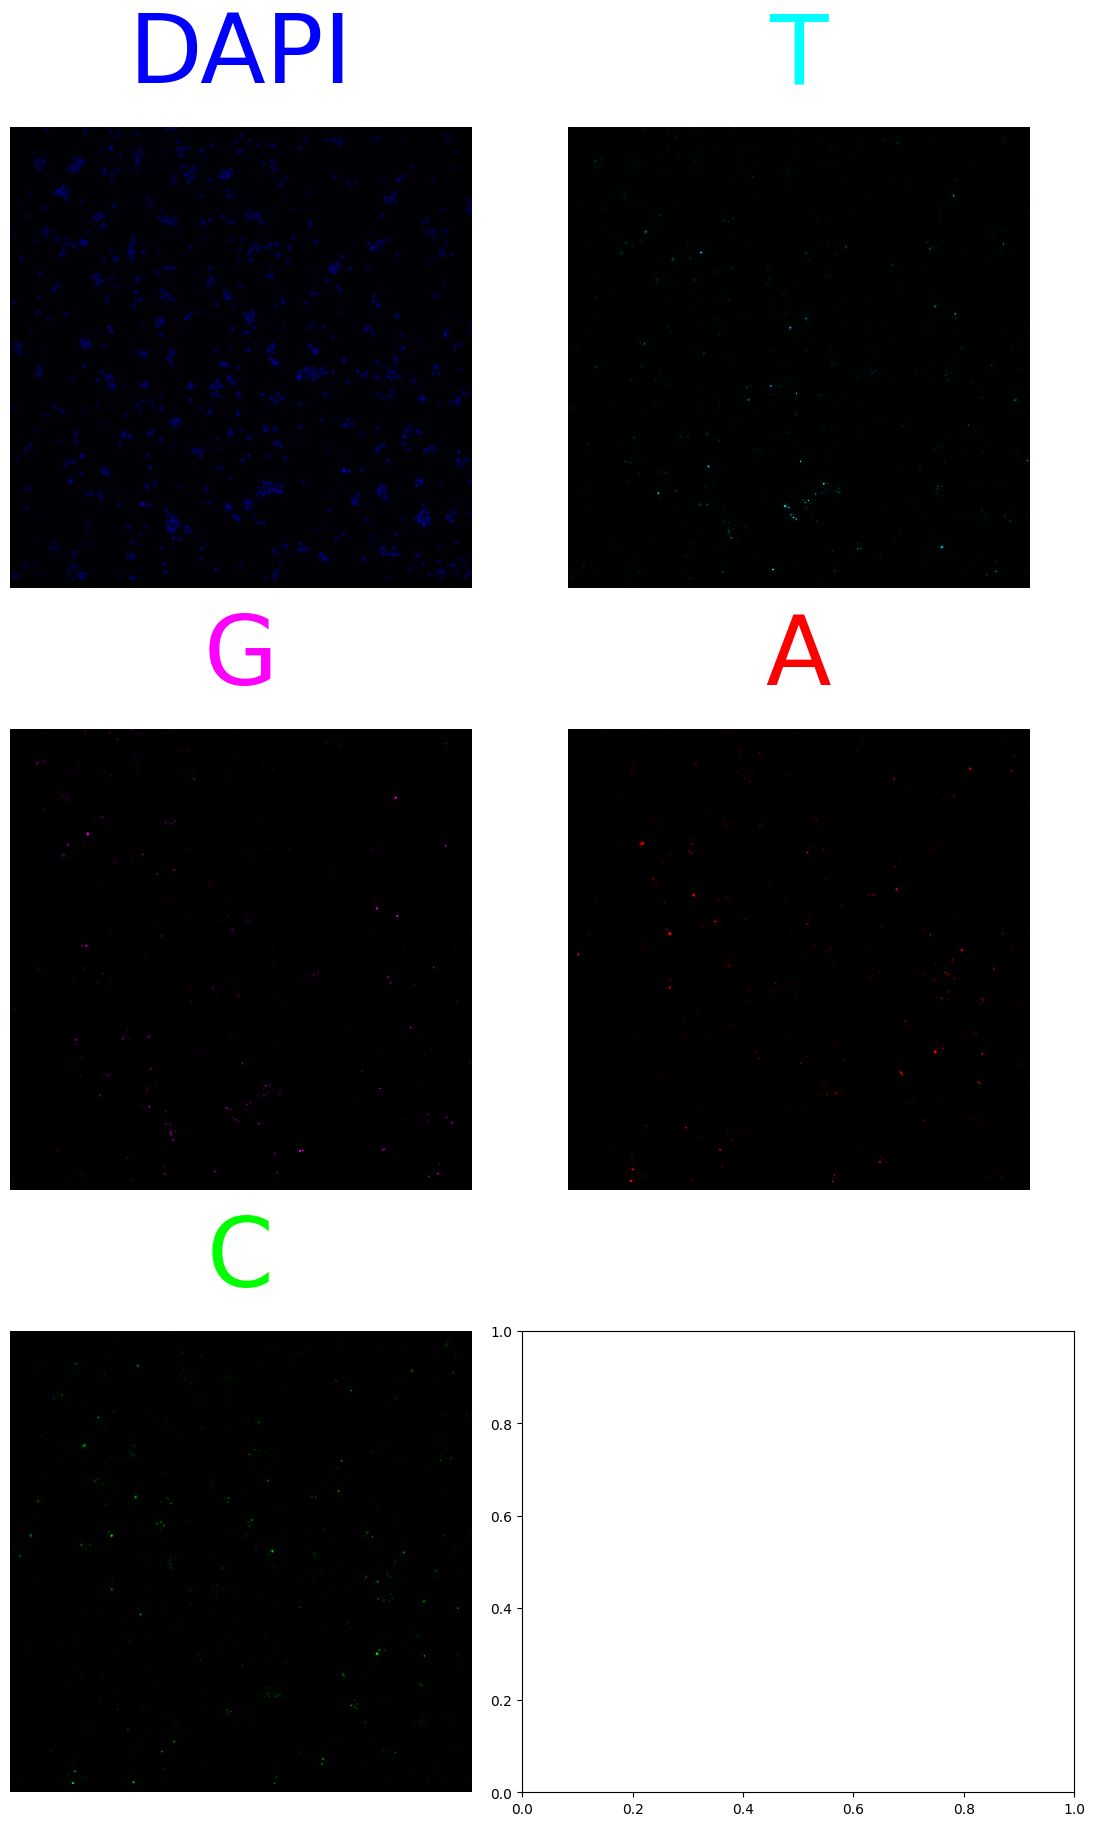

In [8]:
if VIZ_CYCLE is not None:
    print(f"Aligned image for cycle {VIZ_CYCLE + 1}:")
    aligned_microimages = [
        Microimage(
            aligned[VIZ_CYCLE, i, :, :], channel_names=CHANNEL_NAMES[i], cmaps=CHANNEL_CMAPS[i]
        )
        for i in range(aligned.shape[1])
    ]
    aligned_panel = create_micropanel(aligned_microimages, add_channel_label=True)
    plt.show()

Visualizing alignment...


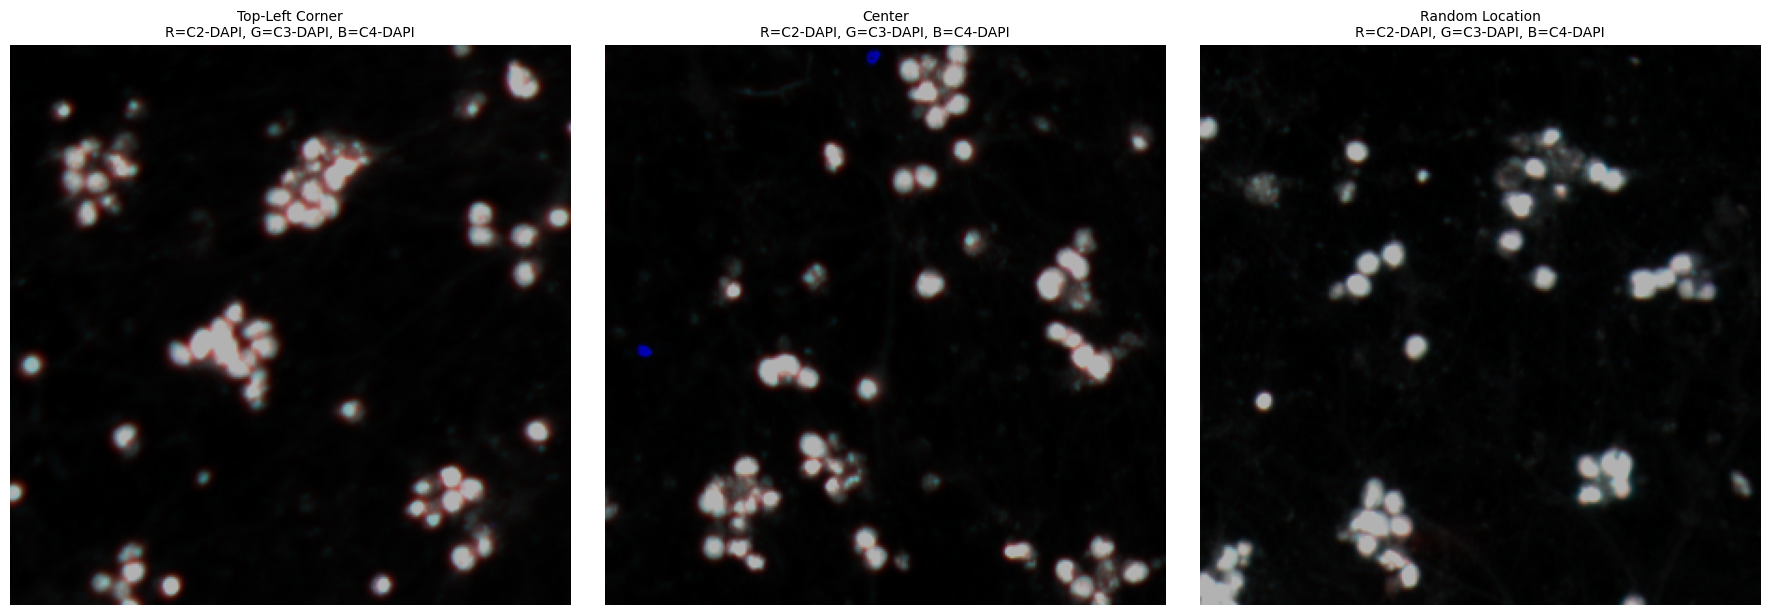

In [9]:
if VIZ_CHANNELS is not None:
    print("Visualizing alignment...")
    alignment_fig = visualize_sbs_alignment(
        aligned, 
        CHANNEL_NAMES,
        DAPI_REFERENCE_CYCLE,
        VIZ_CHANNELS,
        crop_size=300,
        show_dapi=False
    )
    plt.show()

## <font color='red'>SET PARAMETERS</font>

### Spot detection

- `MAX_FILTER_WIDTH`: Width parameter used for determining the neighborhood size for finding local maxima. No default value, but `3` is suggested
- `SPOT_DETECTION_METHOD`: Methodology for calling spots: 
    - `STANDARD`: Standard method for calling spots, involving Laplacian of Gaussian correction, and computation of spots across cycles. Spots are identified based on signal intensity and consistency across cycles.
        - `PEAK_WIDTH`: Width parameter used for peak detection, sets neighborhood size for finding local maxima of base channels standard deviation. Defaults to `5`
    - `SPOTIFLOW`: Deep learning based methodology for calling spots. Spots are called independently on all 4 bases of a selected cycle, and then coalesced to ensure minimum distance between spots. If this method is selected, the following parameters are required:
        - `SPOTIFLOW_CYCLE_INDEX`: Cycle to use for spot detection
        - `SPOTIFLOW_MODEL`: Model to use for spot detection (e.g., "general", "hybiss")
        - `SPOTIFLOW_THRESHOLD`: Probability threshold for confidence in spot detection
        - `SPOTIFLOW_MIN_DISTANCE`: Minimum distance (in pixels) required between detected spots

**Note on Spotiflow:** Spotiflow returns binary spot locations (present/absent) rather than continuous intensity values. As a result, `THRESHOLD_READS` should be set to `0` when using Spotiflow, and the "Mapping rate vs. peak threshold" QC plot will not provide meaningful threshold optimization (all spots have the same binary value).

In [10]:
# Set parameters:
MAX_FILTER_WIDTH = 3
SPOT_DETECTION_METHOD = "spotiflow"

if SPOT_DETECTION_METHOD == "standard":
   PEAK_WIDTH = 5

elif SPOT_DETECTION_METHOD == "spotiflow":
   SPOTIFLOW_CYCLE_INDEX = 0
   SPOTIFLOW_MODEL = "general"
   SPOTIFLOW_THRESHOLD = 0.3 #I'll hve to change these for peak detection (ignore THRESHOLD_PEAK in later section of ntoebook)  
   SPOTIFLOW_MIN_DISTANCE = 3 #Also relevent, not THRESHOLD_PEAK^
# Derive extra channel indices
EXTRA_CHANNEL_INDICES = [CHANNEL_NAMES.index(channel) for channel in EXTRA_CHANNELS]

Detecting candidate reads...
Applying Laplacian-of-Gaussian (LoG) filter...
Applying max filter...
Finding peaks using Spotiflow (model: general)...
Loading Spotiflow 'general' model...
INFO:spotiflow.model.spotiflow:Loading pretrained model: general
Detecting peaks for each base channel using cycle 0...
Processing base channel 1/4...
  Base 1: 1620 spots detected
Processing base channel 2/4...
  Base 2: 1656 spots detected
Processing base channel 3/4...
  Base 3: 1442 spots detected
Processing base channel 4/4...
  Base 4: 1562 spots detected
Combining results from all bases...
Final result: 2320 spots after enforcing minimum distance of 3
Example max filtered image for first cycle:


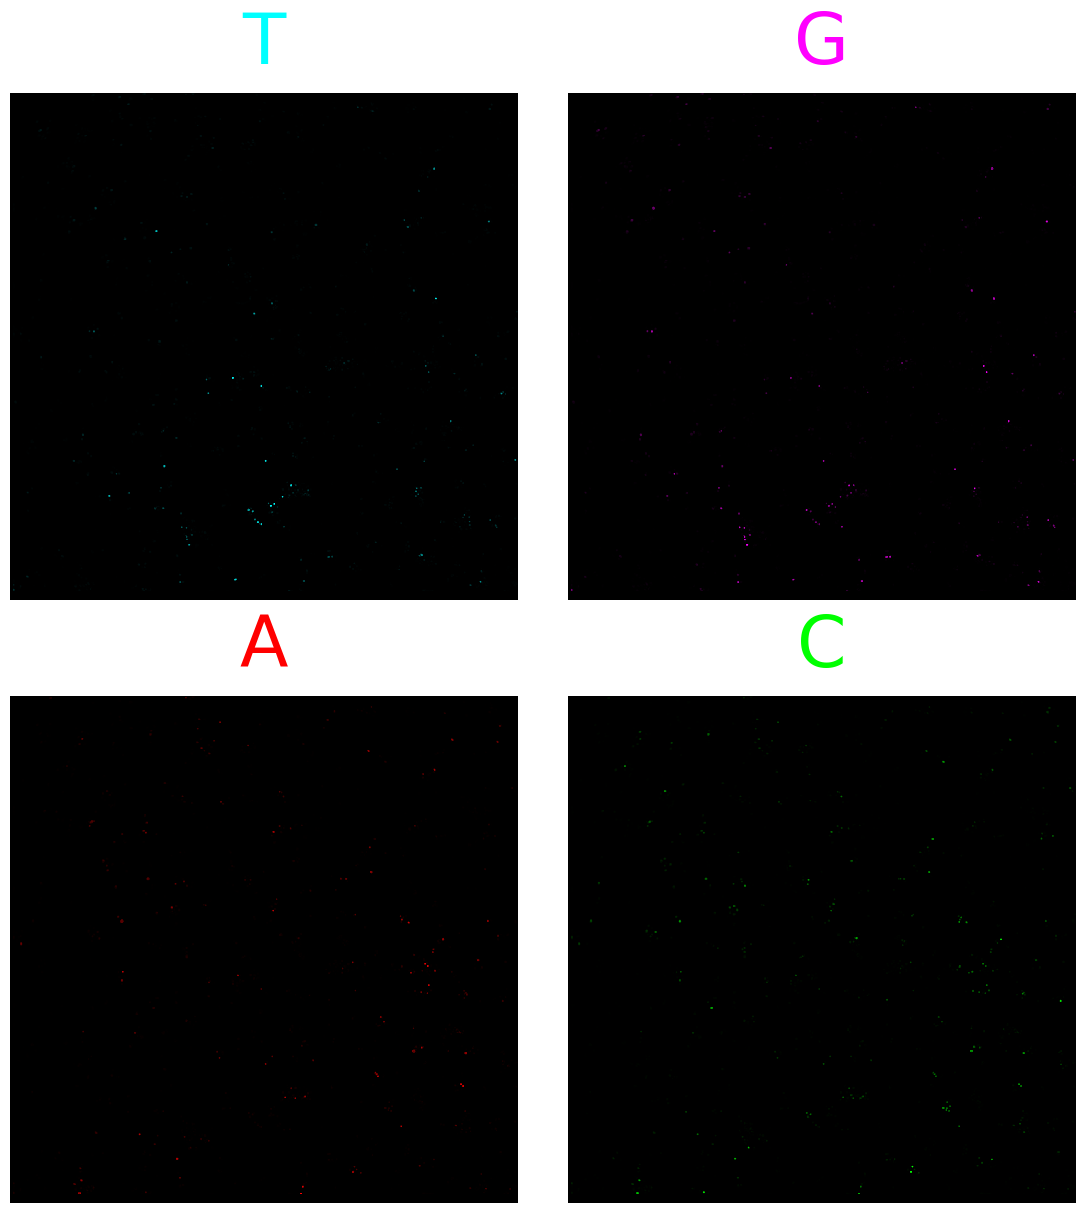

Found 2320 peaks (binary array, non-zero values)


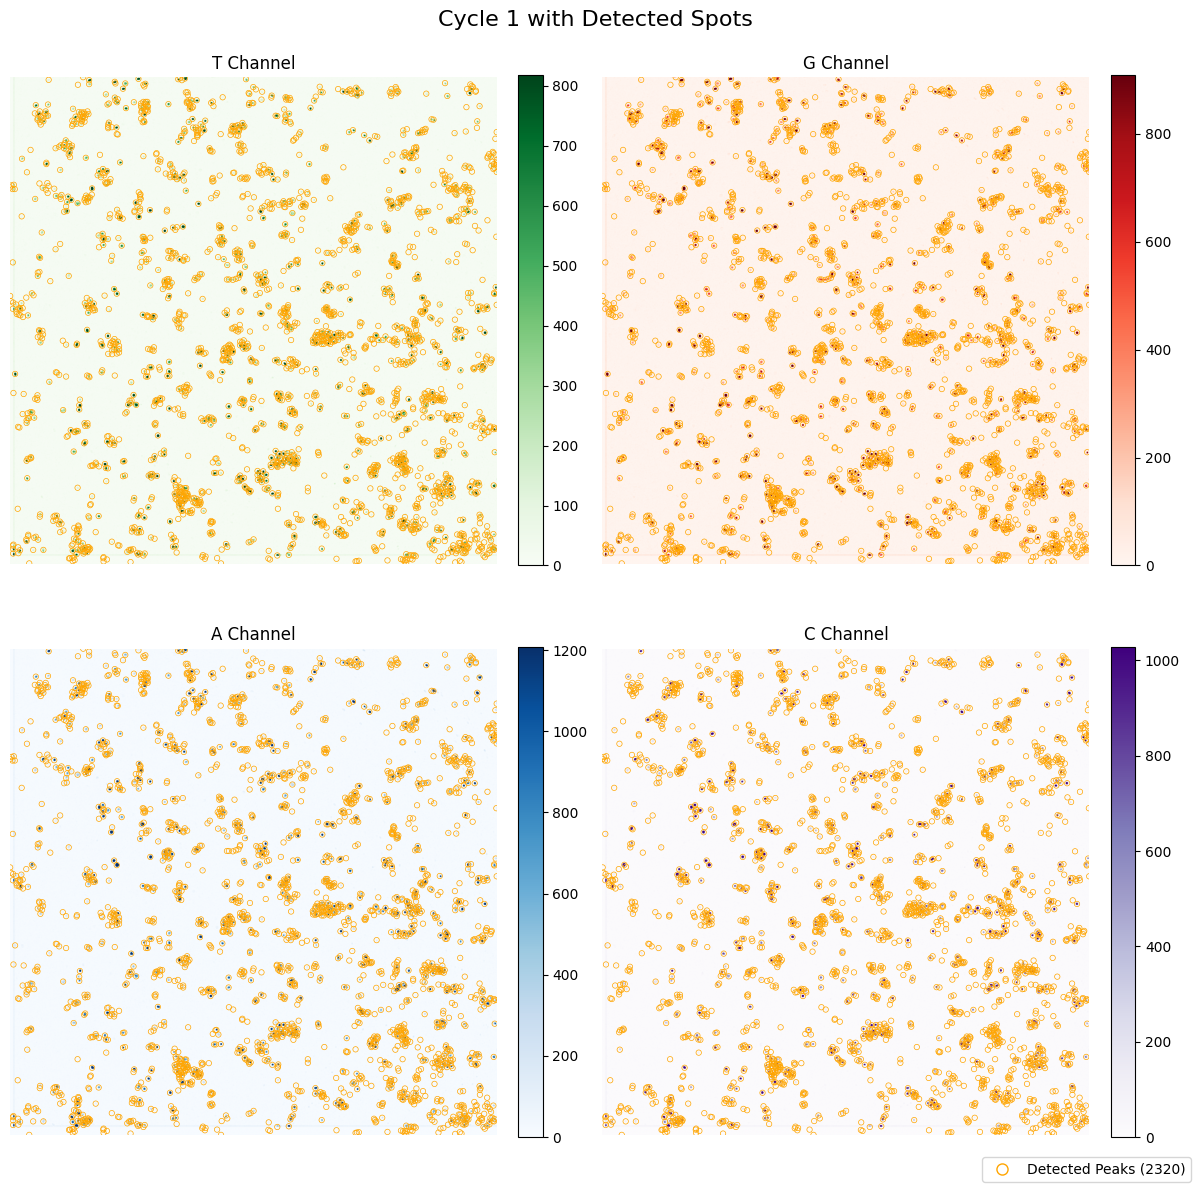

In [11]:
print("Detecting candidate reads...")

print("Applying Laplacian-of-Gaussian (LoG) filter...")
loged = log_filter(aligned, skip_index=EXTRA_CHANNEL_INDICES)

print("Applying max filter...")
maxed = max_filter(loged, width=MAX_FILTER_WIDTH, remove_index=EXTRA_CHANNEL_INDICES)

if SPOT_DETECTION_METHOD == "standard":
    print("Computing standard deviation over cycles...")
    standard_deviation = compute_standard_deviation(loged, remove_index=EXTRA_CHANNEL_INDICES)
    
    print("Finding peaks using standard method...")
    peaks = find_peaks(standard_deviation, width=PEAK_WIDTH)
    
elif SPOT_DETECTION_METHOD == "spotiflow":
    print(f"Finding peaks using Spotiflow (model: {SPOTIFLOW_MODEL})...")
    peaks, _ = find_peaks_spotiflow(
        aligned_images=aligned, 
        cycle_idx=SPOTIFLOW_CYCLE_INDEX,
        model=SPOTIFLOW_MODEL,
        prob_thresh=SPOTIFLOW_THRESHOLD,
        min_distance=SPOTIFLOW_MIN_DISTANCE,
        remove_index=EXTRA_CHANNEL_INDICES,
        verbose=True
    )

# Create and display micropanel of max filtered datas
print("Example max filtered image for first cycle:")
maxed_microimages = [
    Microimage(maxed[1, i, :, :], channel_names=BASES[i], cmaps=CHANNEL_CMAPS[i + 1])
    for i in range(maxed.shape[1])
]
maxed_panel = create_micropanel(maxed_microimages, add_channel_label=True)
plt.show()

# Plot spots on base channels
fig, axes = plot_channels_with_peaks(
    maxed,                 
    peaks,
    BASES,        
    cycle_number=1,   
    threshold_peaks=200 if SPOT_DETECTION_METHOD == "standard" else None,
    peak_colors=['orange'],
    peak_labels=['Detected Peaks']
)
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Illumination Correction and Segmentation

These parameters specify which cycle and channels to use for segmentation.

- `DAPI_CYCLE`: Cycle number containing DAPI. 
- `CYTO_CYCLE`: Optional. Cycle number for the cytoplasmic channel.
- `CYTO_CHANNEL`: Name of the channel used for cell boundary detection.

**Common Configurations:**

1. **Using a cellular stain** (recommended): Set `DAPI_CYCLE = CYTO_CYCLE` to the cycle containing both DAPI and your stain.
   - Example: `DAPI_CYCLE = 1`, `CYTO_CYCLE = 1`, `CYTO_CHANNEL = "Vimentin"`

2. **No cellular stain available**: Set `CYTO_CYCLE` to any cycle and use a base channel (G, T, A, or C) for cytoplasm detection. Common to use a later cycle for increased background signal
   - Example: `DAPI_CYCLE = 1`, `CYTO_CYCLE = 5`, `CYTO_CHANNEL = "G"`

**Note:** If you don't need cell segmentation (nuclei-only), use configuration 1 and set `SEGMENT_CELLS = False` in the Segmentation section below.

In [12]:
# Define cycle to use for segmentation
DAPI_CYCLE = 2 #careful in case i drop cycle 1 later since 443 lib only has T,A (or G,C?) for first cycle
CYTO_CYCLE = 1 #I want cytoplasm segmentation for JF608 dye to help me register with voltage traces, so I need earliest cycle with least bleaching
# Define cytoplasmic channel
CYTO_CHANNEL = "A"

# Derive DAPI and CYTO indexes
DAPI_INDEX = CHANNEL_NAMES.index("DAPI")
CYTO_INDEX = CHANNEL_NAMES.index(CYTO_CHANNEL)
DAPI_CYCLE_INDEX = SBS_CYCLES.index(DAPI_CYCLE) - len([skip for skip in (SKIP_CYCLES or []) if skip < SBS_CYCLES.index(DAPI_CYCLE)])
CYTO_CYCLE_INDEX = SBS_CYCLES.index(CYTO_CYCLE) - len([skip for skip in (SKIP_CYCLES or []) if skip < SBS_CYCLES.index(CYTO_CYCLE)])

# Validate DAPI and CYTO cycles and channels
if DAPI_CYCLE != CYTO_CYCLE and CYTO_CHANNEL not in BASES:
    raise ValueError(
        f"When DAPI_CYCLE ({DAPI_CYCLE}) != CYTO_CYCLE ({CYTO_CYCLE}), "
        f"CYTO_CHANNEL should be a base channel {BASES}, but got '{CYTO_CHANNEL}'. "
        f"If using a cellular stain, set DAPI_CYCLE = CYTO_CYCLE."
    )

DAPI cycle (2) != CYTO cycle (1)
Combining image data and IC fields from both cycles...
Applying illumination correction to segmentation cycle image...
Preparing IC segmentation image for CellPose...
Pre-segmentation images:


/home/jovyan/conda_envs/brieflow-2026-04-6GP002/lib/python3.11/site-packages/skimage/util/dtype.py:576: UserWarning: Downcasting uint16 to uint8 without scaling because max value 0 fits in uint8
  return _convert(image, np.uint8, force_copy)


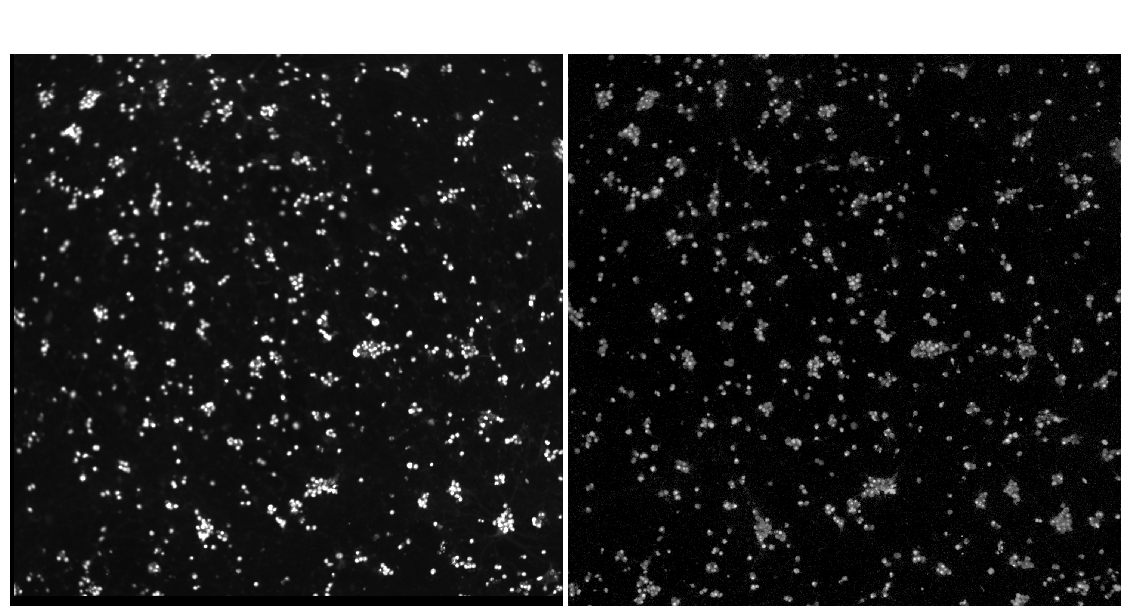

In [13]:
# Logic based on whether DAPI and CYTO come from same or different cycles
if DAPI_CYCLE != CYTO_CYCLE:
    # Different cycles - need to combine image data AND IC fields from both cycles
    print(f"DAPI cycle ({DAPI_CYCLE}) != CYTO cycle ({CYTO_CYCLE})")
    print("Combining image data and IC fields from both cycles...")
    
    # Combine image data from both cycles (DAPI channels from DAPI cycle, base channels from CYTO cycle)
    aligned_image_data_segmentation_cycle = combine_ic_images(
        [aligned[DAPI_CYCLE_INDEX], aligned[CYTO_CYCLE_INDEX]],
        [EXTRA_CHANNEL_INDICES, None],
    )
    
    # Load and combine IC fields
    ic_field_dapi = imread(
        PREPROCESS_FP / "ic_fields" / "sbs" / 
        get_filename({"plate": TEST_PLATE, "well": TEST_WELL, "cycle": DAPI_CYCLE}, "ic_field", "tiff")
    )
    ic_field_cyto = imread(
        PREPROCESS_FP / "ic_fields" / "sbs" / 
        get_filename({"plate": TEST_PLATE, "well": TEST_WELL, "cycle": CYTO_CYCLE}, "ic_field", "tiff")
    )
    ic_field = combine_ic_images([ic_field_dapi, ic_field_cyto], [EXTRA_CHANNEL_INDICES, None])
else:
    # Same cycle - use single cycle for both image data and IC field
    aligned_image_data_segmentation_cycle = aligned[CYTO_CYCLE_INDEX]
    ic_field = imread(
        PREPROCESS_FP / "ic_fields" / "sbs" / 
        get_filename({"plate": TEST_PLATE, "well": TEST_WELL, "cycle": DAPI_CYCLE}, "ic_field", "tiff")
    )

print("Applying illumination correction to segmentation cycle image...")
# Apply illumination correction field
corrected_image = apply_ic_field(
    aligned_image_data_segmentation_cycle, correction=ic_field
)

# Prepare corrected image for CellPose segmentation
# NOTE: this process is done during the `segment_cellpose`` method below as well
# Use the prepared_cellpose image to test CellPose (see below)
print("Preparing IC segmentation image for CellPose...")
cellpose_rgb = prepare_cellpose(
    corrected_image,
    DAPI_INDEX,
    CYTO_INDEX,
)

# show max filtered data for one round
print("Pre-segmentation images:")
pre_seg_microimages = [
    Microimage(cellpose_rgb[2], channel_names="Dapi"),
    Microimage(cellpose_rgb[1], channel_names="Cyto"),
]
pre_seg_panel = create_micropanel(pre_seg_microimages, add_channel_label=True)
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Segmentation

**IMPORTANT: GPU Recommendation for CPSAM**
If testing the CPSAM model (`cellpose_model="cpsam"`), we strongly recommend:
- Using a GPU-enabled machine (`GPU=True`)
- Allocating sufficient time (segmentation can take 30+ minutes per tile)
- Consider running this notebook in a GPU-enabled environment or testing on a smaller region

#### Select Segmentation Method
- `SEGMENTATION_METHOD`: Choose from "cellpose", "stardist", or "watershed" for cell segmentation.

#### Common Parameters
- `GPU`: Set to True to use GPU acceleration (if available).
- `RECONCILE`: Method for reconciling nuclei and cell masks (typically "contained_in_cells", which allows more than one nucleus per cell and is useful for cells that are dividing).
- `SEGMENT_CELLS`: Whether to segment cells, or only segment nuclei. If spots are contained in nuclei, there is no need to segment cell bodies. This may speed up analysis.

#### Cellpose Parameters (if using "cellpose")
- `CELLPOSE_MODEL`: CellPose model to use. Options: "cyto3" (default), "cyto2", "cyto", "nuclei", or "cpsam" (requires Cellpose 4.x).
  - When `SEGMENT_CELLS = True`: The "nuclei" model is always used for nuclei segmentation, and `CELLPOSE_MODEL` is used for cell segmentation.
  - When `SEGMENT_CELLS = False`: `CELLPOSE_MODEL` is used directly for nuclei segmentation. The default "cyto3" works well, but you can set to "nuclei" if preferred.
  - For CPSAM: The "cpsam" model is used for both nuclei and cells regardless of `SEGMENT_CELLS`.
- `CELL_FLOW_THRESHOLD` & `NUCLEI_FLOW_THRESHOLD`: Flow threshold for Cellpose segmentation. Default is 0.4.
- `CELL_CELLPROB_THRESHOLD` & `NUCLEI_CELLPROB_THRESHOLD`: Cell probability threshold for Cellpose. Default is 0.
- `HELPER_INDEX`: (Optional) Index of additional channel to help with CPSAM segmentation. Only used with `cellpose_model="cpsam"`. Default is None.
- Note: For Cellpose 3.x models (cyto3, cyto2), nuclei and cell diameters will be estimated automatically. For CPSAM (Cellpose 4.x), diameters can be left as None and will be estimated from initial segmentation results.

#### StarDist Parameters (if using "stardist")
- `STARDIST_MODEL`: StarDist model type. Default is "2D_versatile_fluo".
- `CELL_PROB_THRESHOLD` & `NUCLEI_PROB_THRESHOLD`: Probability threshold for segmentation. Default is 0.479071.
- `CELL_NMS_THRESHOLD` & `NUCLEI_NMS_THRESHOLD`: Non-maximum suppression threshold. Default is 0.3.

#### Watershed Parameters (if using "watershed")
- `THRESHOLD_DAPI`: Threshold for nuclei segmentation. 
- `THRESHOLD_CELL`: Threshold for cell boundary segmentation.
- `NUCLEUS_AREA`: Range for filtering nuclei by area as a tuple (min, max).

In [14]:
# What if i pass a voltage average image to the cell segmentation function to generate a mask using the same segmentation parameters 
# that generates the mask for the "A" channel (CYTO-CHANNEL), then align the voltage mask with the CYTO_CHANNEL masks 
# for registration of traces to brieflow spots? Claude help me find function?? calls to the functions that can help me accomplish this.

In [15]:
# Select segmentation method
SEGMENTATION_METHOD = "cellpose"

# Common parameters
GPU = False
RECONCILE = "contained_in_cells" ### WHAT SHOULD MY RECONCILE METHOD BE? Options = 'consensus': Only keep nucleus-cell pairs where label matches are unique. 'contained_in_cells': Keep multiple nuclei for a single cell but merge them. (from lib.shared.segment_cellpose import reconcile_nuclei_cells)
SEGMENT_CELLS = True

if SEGMENTATION_METHOD == "cellpose":
    # Parameters for CellPose method
    CELLPOSE_MODEL = "cyto3"
    NUCLEI_FLOW_THRESHOLD = 0.4 #0.4 default
    NUCLEI_CELLPROB_THRESHOLD = 0
    CELL_FLOW_THRESHOLD = 1 #1 default 
    CELL_CELLPROB_THRESHOLD = 0
    HELPER_INDEX = None  # Optional: channel index to help with CPSAM segmentation

    # Only estimate diameters for non-CPSAM models
    if CELLPOSE_MODEL != "cpsam":
        from lib.shared.segment_cellpose import estimate_diameters
        print("Estimating optimal cell and nuclei diameters...")
        NUCLEI_DIAMETER, CELL_DIAMETER = estimate_diameters(
            corrected_image,
            dapi_index=DAPI_INDEX,
            cyto_index=CYTO_INDEX,
            cellpose_model=CELLPOSE_MODEL,
        )
    else:
        print("CPSAM model selected. Initial diameters set to None.")
        print("Note: Diameters will be estimated automatically from segmentation results in the next cell.")
        NUCLEI_DIAMETER = None  # Will be estimated from segmentation
        CELL_DIAMETER = None    # Will be estimated from segmentation

elif SEGMENTATION_METHOD == "stardist":
    # Parameters for StarDist method
    STARDIST_MODEL = "2D_versatile_fluo"
    NUCLEI_PROB_THRESHOLD = 0.479071
    NUCLEI_NMS_THRESHOLD = 0.3
    CELL_PROB_THRESHOLD = 0.479071
    CELL_NMS_THRESHOLD = 0.3

elif SEGMENTATION_METHOD == "watershed":
    # Parameters for Watershed method
    THRESHOLD_DAPI = 4260 
    THRESHOLD_CELL = 1300
    NUCLEUS_AREA = (45,450)

Estimating optimal cell and nuclei diameters...
Estimating nuclei diameters...
Estimated nuclear diameter: 8.1 pixels
Estimating cell diameters...
Estimated cell diameter: 16.5 pixels


Segmenting image with cellpose...


found 892 nuclei before removing edges
found 832 cells before removing edges
found 882 nuclei before reconciling
found 808 cells before reconciling


removing edges
reconciling masks with method how=contained_in_cells

Nuclei per cell statistics:
--------------------------
Cells with 0 nuclei: 57
Cells with 1 nuclei: 698
Cells with 2 nuclei: 50
Cells with 3 nuclei: 2
Cells with 4 nuclei: 1
--------------------------



found 751 nuclei/cells after reconciling


Number of nuclei segmented: 751
Number of cells segmented: 751
Example microplots for DAPI channel and nuclei segmentation:


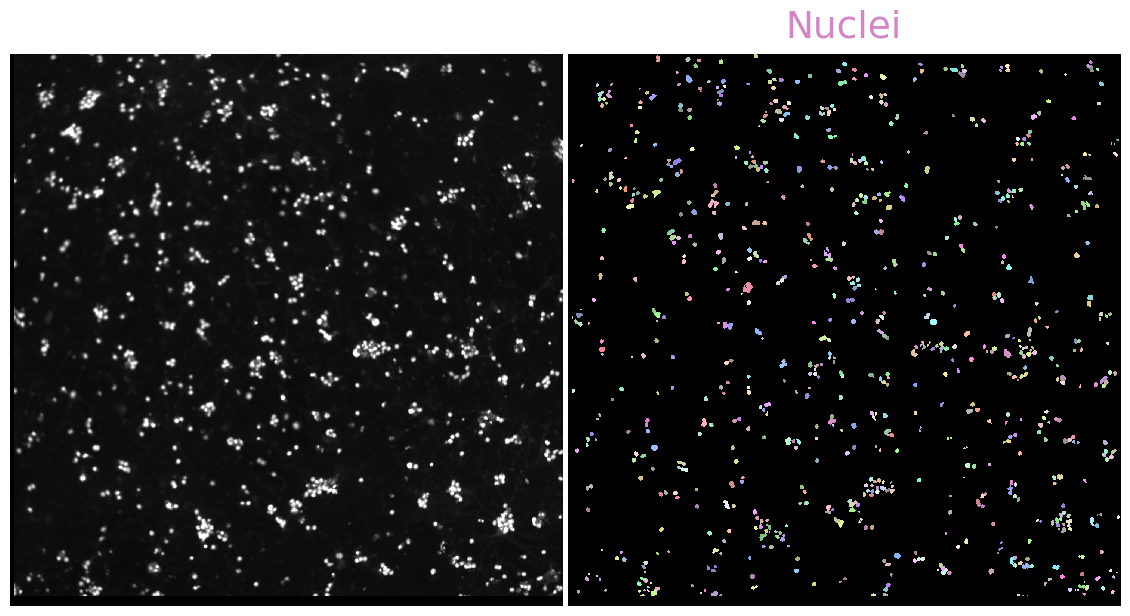

Example microplots for merged channels and cells segmentation:


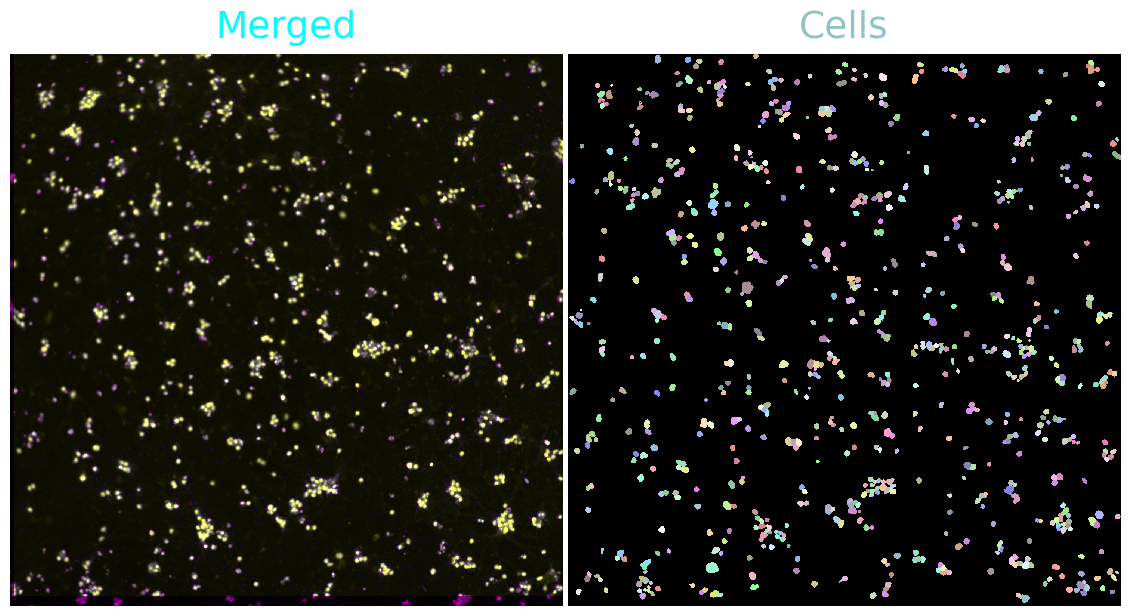

Example microplot for sequencing data annotated with segmentation:


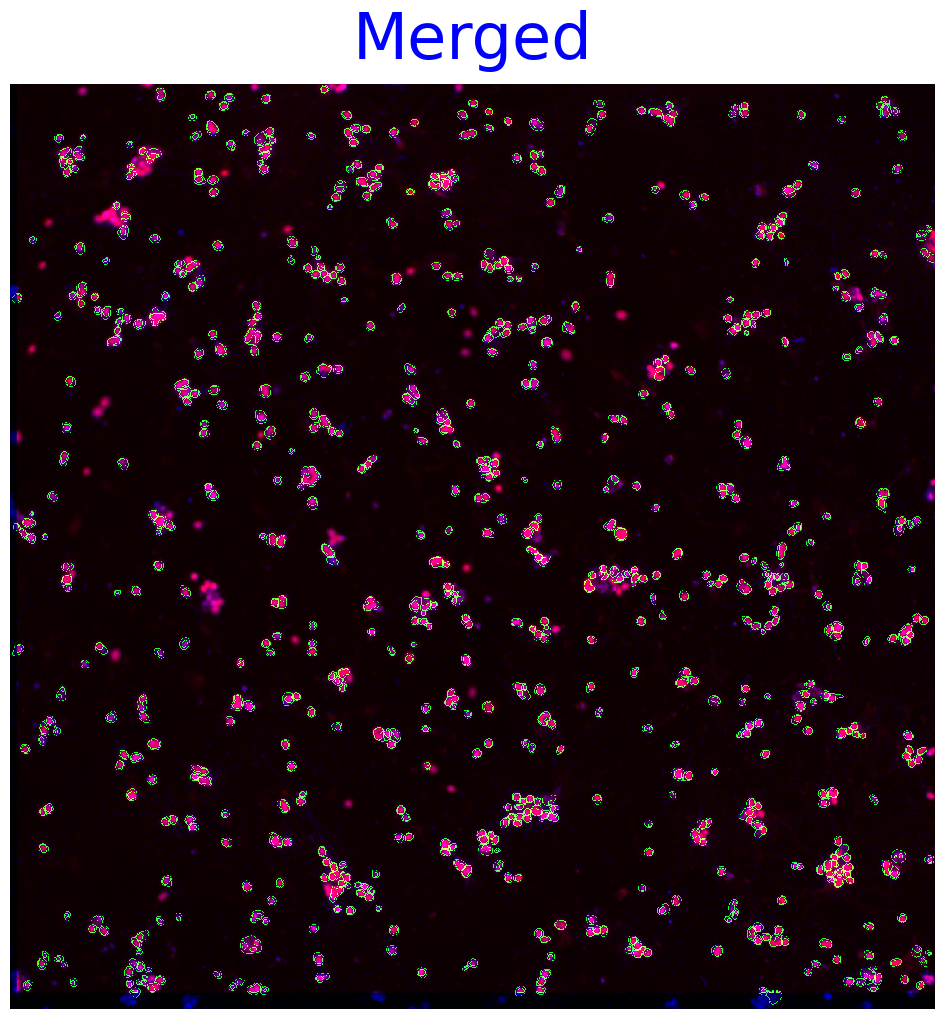

In [16]:
print(f"Segmenting image with {SEGMENTATION_METHOD}...")

if SEGMENTATION_METHOD == "cellpose":
    from lib.shared.segment_cellpose import segment_cellpose
    result = segment_cellpose(
        corrected_image,
        dapi_index=DAPI_INDEX,
        cyto_index=CYTO_INDEX,
        nuclei_diameter=NUCLEI_DIAMETER,
        cell_diameter=CELL_DIAMETER,
        cellpose_kwargs=dict(
            nuclei_flow_threshold=NUCLEI_FLOW_THRESHOLD,
            nuclei_cellprob_threshold=NUCLEI_CELLPROB_THRESHOLD,
            cell_flow_threshold=CELL_FLOW_THRESHOLD,
            cell_cellprob_threshold=CELL_CELLPROB_THRESHOLD,
        ),
        cellpose_model=CELLPOSE_MODEL,
        helper_index=HELPER_INDEX,
        gpu=GPU,
        reconcile=RECONCILE,
        cells=SEGMENT_CELLS,
    )

elif SEGMENTATION_METHOD == "stardist":
    from lib.shared.segment_stardist import segment_stardist
    result = segment_stardist(
        corrected_image,
        dapi_index=DAPI_INDEX,
        cyto_index=CYTO_INDEX,
        model_type=STARDIST_MODEL,
        stardist_kwargs=dict(
            nuclei_prob_threshold=NUCLEI_PROB_THRESHOLD,
            nuclei_nms_threshold=NUCLEI_NMS_THRESHOLD,
            cell_prob_threshold=CELL_PROB_THRESHOLD,
            cell_nms_threshold=CELL_NMS_THRESHOLD,
        ),
        gpu=GPU,
        reconcile=RECONCILE,
        cells=SEGMENT_CELLS,
    )

elif SEGMENTATION_METHOD == "watershed":
    from lib.shared.segment_watershed import segment_watershed
    result = segment_watershed(
        corrected_image,
        nuclei_threshold=THRESHOLD_DAPI,
        nuclei_area_min=NUCLEUS_AREA[0],
        nuclei_area_max=NUCLEUS_AREA[1],
        cell_threshold=THRESHOLD_CELL,
        cells=SEGMENT_CELLS,
    )

# Handle unpacking based on SEGMENT_CELLS
if SEGMENT_CELLS:
    nuclei, cells = result
else:
    nuclei = result
    cells = nuclei  # Use nuclei as cells for downstream code compatibility

# Create and display micropanel of nuclei segmention
print("Example microplots for DAPI channel and nuclei segmentation:")
nuclei_cmap = random_cmap(num_colors=len(np.unique(nuclei)))
nuclei_seg_microimages = [
    Microimage(cellpose_rgb[2], channel_names="Dapi"),
    Microimage(nuclei, cmaps=nuclei_cmap, channel_names="Nuclei"),
]
nuclei_seg_panel = create_micropanel(nuclei_seg_microimages, add_channel_label=True)
plt.show()

# Create and display micropanel of segmented cells
print(f"Example microplots for merged channels and {'cells' if SEGMENT_CELLS else 'nuclei'} segmentation:")
cells_cmap = random_cmap(num_colors=len(np.unique(cells if SEGMENT_CELLS else nuclei)))
cells_seg_microimages = [
    Microimage(cellpose_rgb, channel_names="Merged"),
    Microimage(cells if SEGMENT_CELLS else nuclei, cmaps=cells_cmap, channel_names="Cells" if SEGMENT_CELLS else "Nuclei"),
]
cells_seg_panel = create_micropanel(cells_seg_microimages, add_channel_label=True)
plt.show()

# Create and display micropanel of annotated data
print("Example microplot for sequencing data annotated with segmentation:")
annotated_data = image_segmentation_annotations(cellpose_rgb[1:], nuclei, cells if SEGMENT_CELLS else nuclei)
annotated_microimage = [
    Microimage(
        annotated_data,
        channel_names="Merged",
        cmaps=["pure_blue", "pure_red", "pure_green"],
    )
]
annotated_panel = create_micropanel(
    annotated_microimage, num_cols=1, figscaling=10, add_channel_label=True
)
plt.show()

if SEGMENTATION_METHOD == "cellpose" and CELLPOSE_MODEL == "cpsam":
    from skimage.measure import regionprops
    import numpy as np

    # Calculate nuclei diameters
    nuclei_props = regionprops(nuclei)
    nuclei_diameters = [prop.equivalent_diameter for prop in nuclei_props]
    estimated_nuclei_diameter = np.mean(nuclei_diameters)
    print(f"Nuclei - Average diameter: {estimated_nuclei_diameter:.2f} pixels")

    # Calculate cell diameters  
    cells_props = regionprops(cells)
    cells_diameters = [prop.equivalent_diameter for prop in cells_props]
    estimated_cell_diameter = np.mean(cells_diameters)
    print(f"Cells - Average diameter: {estimated_cell_diameter:.2f} pixels")
    
    # Update the diameter variables for config
    NUCLEI_DIAMETER = estimated_nuclei_diameter
    CELL_DIAMETER = estimated_cell_diameter
    print(f"\nUpdated NUCLEI_DIAMETER to {NUCLEI_DIAMETER:.2f} pixels")
    print(f"Updated CELL_DIAMETER to {CELL_DIAMETER:.2f} pixels")

Note: You may want to adjust these parameters and run segmentation tests if you feel you are capturing too little or too much area for the masks. For cellpose, the nuclei and cell diameters will be automatically estimated, but can be manually adjusted if needed. You manually can set `NUCLEI_DIAMETER` and `CELL_DIAMETER` and rerun the above blocks as many times as needed.

## <font color='red'>SET PARAMETERS</font>

### Barcode design table standardization

Raw barcode design tables from different sources often have inconsistent formatting, column names, and gene annotations that need to be cleaned and validated before analysis. This standardization step transforms your raw design file into a consistent format with validated gene symbols, standardized column names, and proper barcode prefixes for read mapping.

**Barcode Type Selection:**
- `BARCODE_TYPE`: Choose "simple" (single-barcode protocol) or "multi" (multi-barcode with MAP/RECOMB regions)
- **Default**: "simple" for standard protocols
- See Cell 32 for detailed explanation of barcode types and when to use each mode

**Essential Parameters:**
- `DF_DESIGN_FP`: File path to your raw guide RNA design file (TSV format)
- `DF_BARCODE_LIBRARY_FP`: File path where the cleaned, standardized barcode library will be saved
- `UNIPROT_DATA_FP`: File path for temporary UniProt annotation data (automatically generated and deleted)
- `GENE_SYMBOL_COL`: Column name containing gene symbols (e.g., "gene_symbol", "target_gene"). Set to `None` if unavailable
- `GENE_ID_COL`: Column name containing gene IDs (e.g., "gene_id", "ensembl_id"). Set to `None` if not needed

**Simple Mode Parameters:**
- `BARCODE_COL`: Column containing full barcode sequences (e.g., "sgRNA", "guide_sequence")
- `PREFIX_LENGTH`: Total barcode length BEFORE skipping cycles
  - Final length = PREFIX_LENGTH - number of skipped cycles
  - Example: 13 bases → skip [2,3,4] → 10 final bases
- `SKIP_CYCLES_MAP`: 1-based cycle positions to skip (e.g., `[2, 3, 4]`)
  - **IMPORTANT**: Must match `SKIP_CYCLES` from Cell 8 (imaging alignment)
  - Set to `None` if no cycles were skipped

**Multi Mode Parameters:**
- `BARCODE_MAP`: Column with MAP region barcode sequences (e.g., "iBAR2")
- `BARCODE_RECOMB`: Column with RECOMB region barcode sequences (optional)
- `MAP_PREFIX_LENGTH`: Total bases BEFORE skipping for MAP region
  - Final length = MAP_PREFIX_LENGTH - len(SKIP_CYCLES_MAP)
- `RECOMB_PREFIX_LENGTH`: Total bases BEFORE skipping for RECOMB region
  - Final length = RECOMB_PREFIX_LENGTH - len(SKIP_CYCLES_RECOMB)
- `SKIP_CYCLES_MAP`: 1-based positions to skip in MAP region (optional)
- `SKIP_CYCLES_RECOMB`: 1-based positions to skip in RECOMB region (optional)
- `SEQUENCING_ORDER`: Order of barcode regions during sequencing. Options are:
    - `"map_recomb"`: MAP region sequenced first, then RECOMB region
    - `"recomb_map"`: RECOMB region sequenced first, then MAP region

**Non-Targeting Control Parameters:**
- `NONTARGETING_FORMAT`: Format string for standardized non-targeting names (default: "nontargeting_{prefix}")
  - Use `{prefix}` for barcode prefix, `{original}` for original name
- `NONTARGETING_PATTERNS`: List of patterns to identify non-targeting controls (default: ["nontargeting", "sg_nt", "non-targeting"])

**Note:** For complex scenarios (custom prefix generation), you can use custom prefix functions (`prefix_map_func`, `prefix_recomb_func`). See function documentation for details.

In [17]:
# Define barcode type
BARCODE_TYPE = "multi"

# Essential parameters (common to both modes)
DF_DESIGN_FP = "ASD_CSMT7_library_design_091024.txt" #this is the input 443 iBAR library that Brian sent me + 5GP of Jinfan and Jax constructs
DF_BARCODE_LIBRARY_FP = "config/barcode_library.tsv"
UNIPROT_DATA_FP = "config/uniprot_data.tsv"
GENE_SYMBOL_COL = "target"
GENE_ID_COL = None

# Non-targeting control parameters
NONTARGETING_PATTERN_MAP = {
                "non-target": "nontargeting_non-target-{prefix}",
                "safe-target": "nontargeting_safe-target-{prefix}"
            }  # Use {prefix} for barcode prefix; Note "nontargeting_" prefix is because the function standardize_barcode_design hardcoded "nontargeting_" as the necessary prefix for a gene to be recognized as a control
NONTARGETING_FORMAT = "control-{prefix}"
NONTARGETING_PATTERNS = ["non-target", "safe-target"]  # Patterns to identify controls

# Simple mode parameters (used when BARCODE_TYPE = "simple")
BARCODE_COL = None  # Column with full barcode sequences
# IMPORTANT: PREFIX_LENGTH should be the FULL barcode length in your design library
# If you skipped cycles during imaging (Cell 8: SKIP_CYCLES), use SKIP_CYCLES_MAP below
PREFIX_LENGTH = None  # Full barcode length (e.g., 12 for 12-base barcodes)
# If you skipped cycles during imaging, set this to match SKIP_CYCLES from Cell 8
# Example: SKIP_CYCLES = [1, 6] in Cell 8 → SKIP_CYCLES_MAP = [1, 6] here
SKIP_CYCLES_MAP = None  # Set to list of 1-based cycle numbers to skip, or None if no cycles skipped

# Multi mode parameters (used when BARCODE_TYPE = "multi")
BARCODE_MAP = "iBAR_2"  # Column with MAP region barcode sequences (e.g., "iBAR2")
BARCODE_RECOMB = "iBAR_1"  # Column with RECOMB region barcode sequences (optional) ## (AB) IS THIS IBAR_1? ##
MAP_PREFIX_LENGTH = 12  # Length of MAP prefix to extract (e.g., 6 for cycles 0-5)
RECOMB_PREFIX_LENGTH = 5  # Length of RECOMB prefix to extract (e.g., 6 for cycles 6-11)
SKIP_CYCLES_RECOMB = None  # Optional: list of 1-based cycles to skip in RECOMB region
SEQUENCING_ORDER = "map_recomb"  # Options: "map_recomb" or "recomb_map"

In [18]:
# Fallback script location + persistent raw master (survives the unlink later in the cell).
import sys
SCRIPTS_AB_DIR = "/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/analysis/scripts_AB"
UNIPROT_RAW_MASTER_FP = "/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/analysis/uniprot_human_reviewed_raw.tsv"
if SCRIPTS_AB_DIR not in sys.path:
    sys.path.insert(0, SCRIPTS_AB_DIR)

# Get uniprot data and save it temporarily.
try:
    # Primary path: live REST call via brieflow.
    uniprot_data = get_uniprot_data()
    uniprot_data.to_csv(UNIPROT_DATA_FP, sep="\t", index=False)
except Exception as e:
    # Fallback: UniProt's edge is dropping the default python-requests client.
    # The curl-based downloader writes the post-processed file to UNIPROT_DATA_FP
    # and keeps a persistent raw master at UNIPROT_RAW_MASTER_FP.
    print(f"Live UniProt call failed ({type(e).__name__}: {e}). Falling back to curl download...")
    from fetch_uniprot_fallback import fetch_uniprot_fallback
    fetch_uniprot_fallback(UNIPROT_DATA_FP, UNIPROT_RAW_MASTER_FP, species_id="9606")

# Get uniprot data and save it temporarily
#uniprot_data = get_uniprot_data()
#uniprot_data.to_csv(UNIPROT_DATA_FP, sep="\t", index=False)

uniprot_data = pd.read_csv(UNIPROT_DATA_FP, sep="\t")
# Read design table
print("Loading and standardizing barcode design table...")
df_design = pd.read_csv(DF_DESIGN_FP, sep="\t")

# Call standardize_barcode_design with mode-specific parameters
if BARCODE_TYPE == "simple":
    # Simple mode: use barcode_col and prefix_length (legacy parameter names)
    df_barcode_library = standardize_barcode_design(
        df_design,
        prefix_map=BARCODE_COL,  # In simple mode, this is the barcode column
        gene_symbol_col=GENE_SYMBOL_COL,
        gene_id_col=GENE_ID_COL,
        map_prefix_length=PREFIX_LENGTH,  # In simple mode, this is the prefix length
        skip_cycles_map=SKIP_CYCLES_MAP,  # Pass skip_cycles for simple mode
        uniprot_data_path=UNIPROT_DATA_FP,
        nontargeting_format=NONTARGETING_FORMAT,
        nontargeting_patterns=NONTARGETING_PATTERNS,
    )
    
elif BARCODE_TYPE == "multi":
    # Multi mode: use prefix_map, prefix_recomb, and region-specific lengths
    df_barcode_library = standardize_barcode_design(
        df_design,
        prefix_map=BARCODE_MAP,
        prefix_recomb=BARCODE_RECOMB,
        gene_symbol_col=GENE_SYMBOL_COL,
        gene_id_col=GENE_ID_COL,
        map_prefix_length=MAP_PREFIX_LENGTH,
        recomb_prefix_length=RECOMB_PREFIX_LENGTH,
        skip_cycles_map=SKIP_CYCLES_MAP,
        skip_cycles_recomb=SKIP_CYCLES_RECOMB,
        uniprot_data_path=UNIPROT_DATA_FP,
        nontargeting_format=NONTARGETING_FORMAT,
        nontargeting_patterns=NONTARGETING_PATTERNS,
        nontargeting_pattern_map=NONTARGETING_PATTERN_MAP,
    )

# Delete uniprot data file
Path(UNIPROT_DATA_FP).unlink(missing_ok=True)

# Save standardized design table
df_barcode_library.to_csv(DF_BARCODE_LIBRARY_FP, sep="\t", index=False)
print(f"Standardized barcode design saved to: {DF_BARCODE_LIBRARY_FP}")
display(df_barcode_library)

# Extract barcodes (prefixes) for mapping - conditional based on barcode type
if BARCODE_TYPE == "multi":
    barcodes = get_barcode_list(df_barcode_library, sequencing_order=SEQUENCING_ORDER)
else:
    barcodes = get_barcode_list(df_barcode_library)
    
print(f"Extracted {len(barcodes)} barcode prefixes for read mapping")

## NOTE gene_symbol column can differentiate safe-target and non-target, while the uniprot_entry column lumps all safe-targets and non-targets as NON_TARGETING_CONTROL

Fetching UniProt data...
Completed. Total entries: 20471
Loading and standardizing barcode design table...
Standardizing barcode design table with 1156 entries...
Renamed 'iBAR_2' column to 'prefix_map'
Renamed 'iBAR_1' column to 'prefix_recomb'
Renamed 'target' column to 'gene_symbol'
Modified 'prefix_map' using truncation (length=12)
Modified 'prefix_recomb' using truncation (length=5)
Applied pattern 'non-target' → 'nontargeting_non-target-{prefix}': 133 controls
Applied pattern 'safe-target' → 'nontargeting_safe-target-{prefix}': 133 controls

Total standardized non-targeting controls: 266
  - non-target: 133 controls
  - safe-target: 133 controls

Example transformations:
    'non-target' → 'nontargeting_non-target-CCAGCTTCTTGT'
    'non-target' → 'nontargeting_non-target-CCGATGATTCTA'
    'non-target' → 'nontargeting_non-target-CCCAAATGTACA'
Loaded UniProt data: 20471 entries
Removed 125 entries without gene names
Processed UniProt data: 44320 unique gene names
UniProt annotation

,prefix_map,gene_symbol,uniprot_entry,prefix_recomb
level_0,,,,
0,CCATCATGTGGC,ABCC9,O60706,AAAGC
1,TGATGCACTCGG,ABCC9,O60706,GATCA
2,CATAAACAGGCT,ACTB,P60709,GTATG
3,CGCTATTTCTCA,ACTB,P60709,GAAGC
4,TACGATACATCA,ADNP,Q9H2P0,AAAGC
...,...,...,...,...
1151,CAGACAATTTGT,nontargeting_non-target-CAGACAATTTGT,NON_TARGETING_CONTROL,AGTGG
1152,TTCCGTCGATTT,SCN2A,Q99250,GGAGT
1153,GGGCAACACACC,KCNQ2,O43526,CATGC


Extracted 1156 barcode prefixes for read mapping


In [19]:
#check if naming convention for controls is working as intended. Should not see a "264 genes could not be validated" warning
gs = df_barcode_library["gene_symbol"]
print("non-target:",  gs.str.startswith("nontargeting_non-target-").sum())   # expect 131
print("safe-target:", gs.str.startswith("nontargeting_safe-target-").sum())  # expect 133
print("total controls:", gs.str.startswith("nontargeting_").sum())           # expect 264

non-target: 133
safe-target: 133
total controls: 266


## <font color='red'>SET PARAMETERS</font>

### Extract base intensity, call reads, assign to cells
- `THRESHOLD_READS`: Initial threshold for detecting sequencing reads, set to ~50 for preliminary analysis. This parameter will be optimized based on the mapping rate vs. peak threshold plot generated below. A higher threshold increases confidence in read calls but reduces the total number of detected reads.
- `CALL_READS_METHOD`: Method to use for correcting base intensity across channels. The below `plot_normalization_comparison` function will help you assess what method to use. Options are:
    - `MEDIAN`: Uses median-based correction, performed independently for each tile. This is the default method.
    - `PERCENTILE`: Uses percentile-based correction, performed independently for each tile.

In [20]:
# Define parameters for calling reads
THRESHOLD_READS = 0 #spotiflow creates binary mask so threshold only works with standard spot detection (continuous variable output)
CALL_READS_METHOD = "median"

In [21]:
# Run extract_bases and call_reads with the default threshold
df_bases = extract_bases(
    peaks, maxed, cells if SEGMENT_CELLS else nuclei, THRESHOLD_READS, wildcards=WILDCARDS, bases=BASES
)
df_reads = call_reads(df_bases, peaks_data=peaks, method=CALL_READS_METHOD)

/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/brieflow/workflow/lib/sbs/extract_bases.py:134: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df.stack([CYCLE, CHANNEL])


In [22]:
#import numpy as np
#ask = cells if SEGMENT_CELLS else nuclei

#print("maxed:", maxed.shape, maxed.dtype, "ndim", maxed.ndim)   # expect 4-D (CYCLE, CHANNEL, I, J)
#print("peaks:", peaks.shape, peaks.dtype, "ndim", peaks.ndim)   # expect 2-D (I, J)
#print("mask :", mask.shape, mask.dtype)
#print("BASES:", BASES, "len", len(BASES))
#print("THRESHOLD_READS:", THRESHOLD_READS)

#print("cycles  (maxed.shape[0]):", maxed.shape[0])              # must equal your # of SBS cycles
#print("channels(maxed.shape[1]):", maxed.shape[1], "== len(BASES)?", maxed.shape[1] == len(BASES))
#print("spatial maxed[-2:]:", maxed.shape[-2:], "vs peaks:", peaks.shape[-2:])  # must match
#print("candidate reads (peaks > thr):", int((peaks > THRESHOLD_READS).sum()))
#print("maxed NaN?", np.isnan(maxed).any(), "inf?", np.isinf(maxed).any())

#print("\nmaxed range:", maxed.min(), maxed.max(), "mean:", round(float(maxed.mean()), 1))
#print(peaks.dtype, peaks.min(), peaks.max())
#print(np.unique(peaks, return_counts=True))

In [23]:
#from lib.sbs.extract_bases import format_bases, extract_base_intensity
#extract_bases??
#format_bases??           # primary — this is where the message and the reshape live
#extract_base_intensity??  # secondary — this produces the `values` array being reshaped
#extract_base_intensity??
#from lib.sbs.find_peaks import find_peaks, find_peaks_spotiflow
#find_peaks??
#find_peaks_spotiflow??   # if your screen.yaml selects the spotiflow path
#find_peaks_spotiflow??

### Determine Optimal Read Threshold

**These plots show READ-LEVEL metrics** (not final cell-level mapping):
- **Blue line**: Fraction of reads matching expected barcodes
- **Orange solid**: Total reads with valid barcodes  
- **Orange dotted**: Unique cells with ≥1 valid barcode (not necessarily singlets)

Use these to set `THRESHOLD_READS` to maximize clean reads. Final cell-level QC comes later.

Mapping rate vs. Q_min threshold for determining optimal peak cutoff


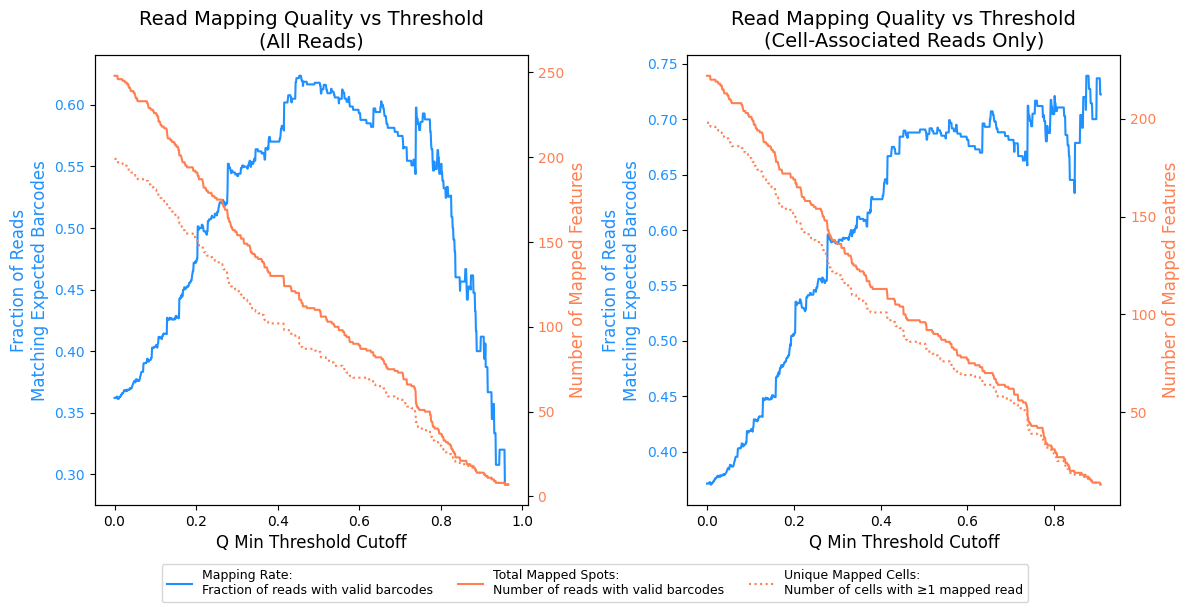

In [24]:
print("Mapping rate vs. Q_min threshold for determining optimal peak cutoff")
plot_mapping_vs_threshold(df_reads, barcodes, threshold_var="Q_min")
plt.show()

**How to read these plots:**
- **Left**: All reads (including background noise)
- **Right**: Cell-associated reads only (cell > 0)

**Goal**: Find threshold where mapping rate plateaus (~70-80%) while retaining enough reads/cells for analysis.

**Note**: High read mapping ≠ high cell mapping. Many reads might cluster in few cells, or cells might have mixed barcodes. See cell-level QC below for final mapping quality.

In [25]:
THRESHOLD_READS = 0

Extracted bases:


/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/brieflow/workflow/lib/sbs/extract_bases.py:134: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df.stack([CYCLE, CHANNEL])


,read,cycle,channel,intensity,cell,i,j,tile,well
0,0,1,T,67,0,0,222,125,A2
1,0,1,G,94,0,0,222,125,A2
2,0,1,A,1279,0,0,222,125,A2
3,0,1,C,2981,0,0,222,125,A2
4,0,2,T,150,0,0,222,125,A2
...,...,...,...,...,...,...,...,...,...
156463,2300,16,C,102,751,1466,1223,125,A2
156464,2300,17,T,108,751,1466,1223,125,A2
156465,2300,17,G,106,751,1466,1223,125,A2
156466,2300,17,A,102,751,1466,1223,125,A2


Base intensity across cycles:


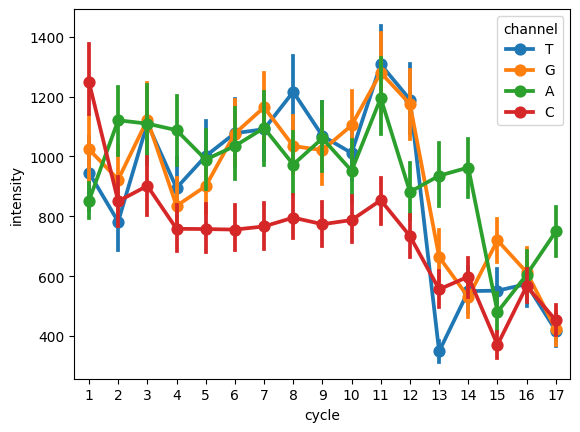

Intensity for each base:


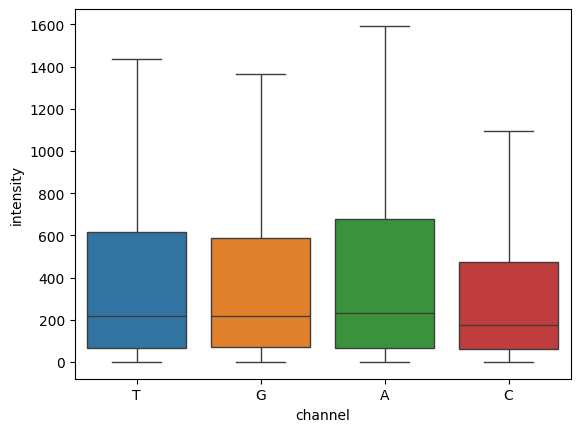

Different normalization methods


/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/brieflow/workflow/lib/sbs/call_reads.py:333: RuntimeWarning: invalid value encountered in divide
  X_rel = X / rowsums
/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/brieflow/workflow/lib/sbs/call_reads.py:333: RuntimeWarning: invalid value encountered in divide
  X_rel = X / rowsums


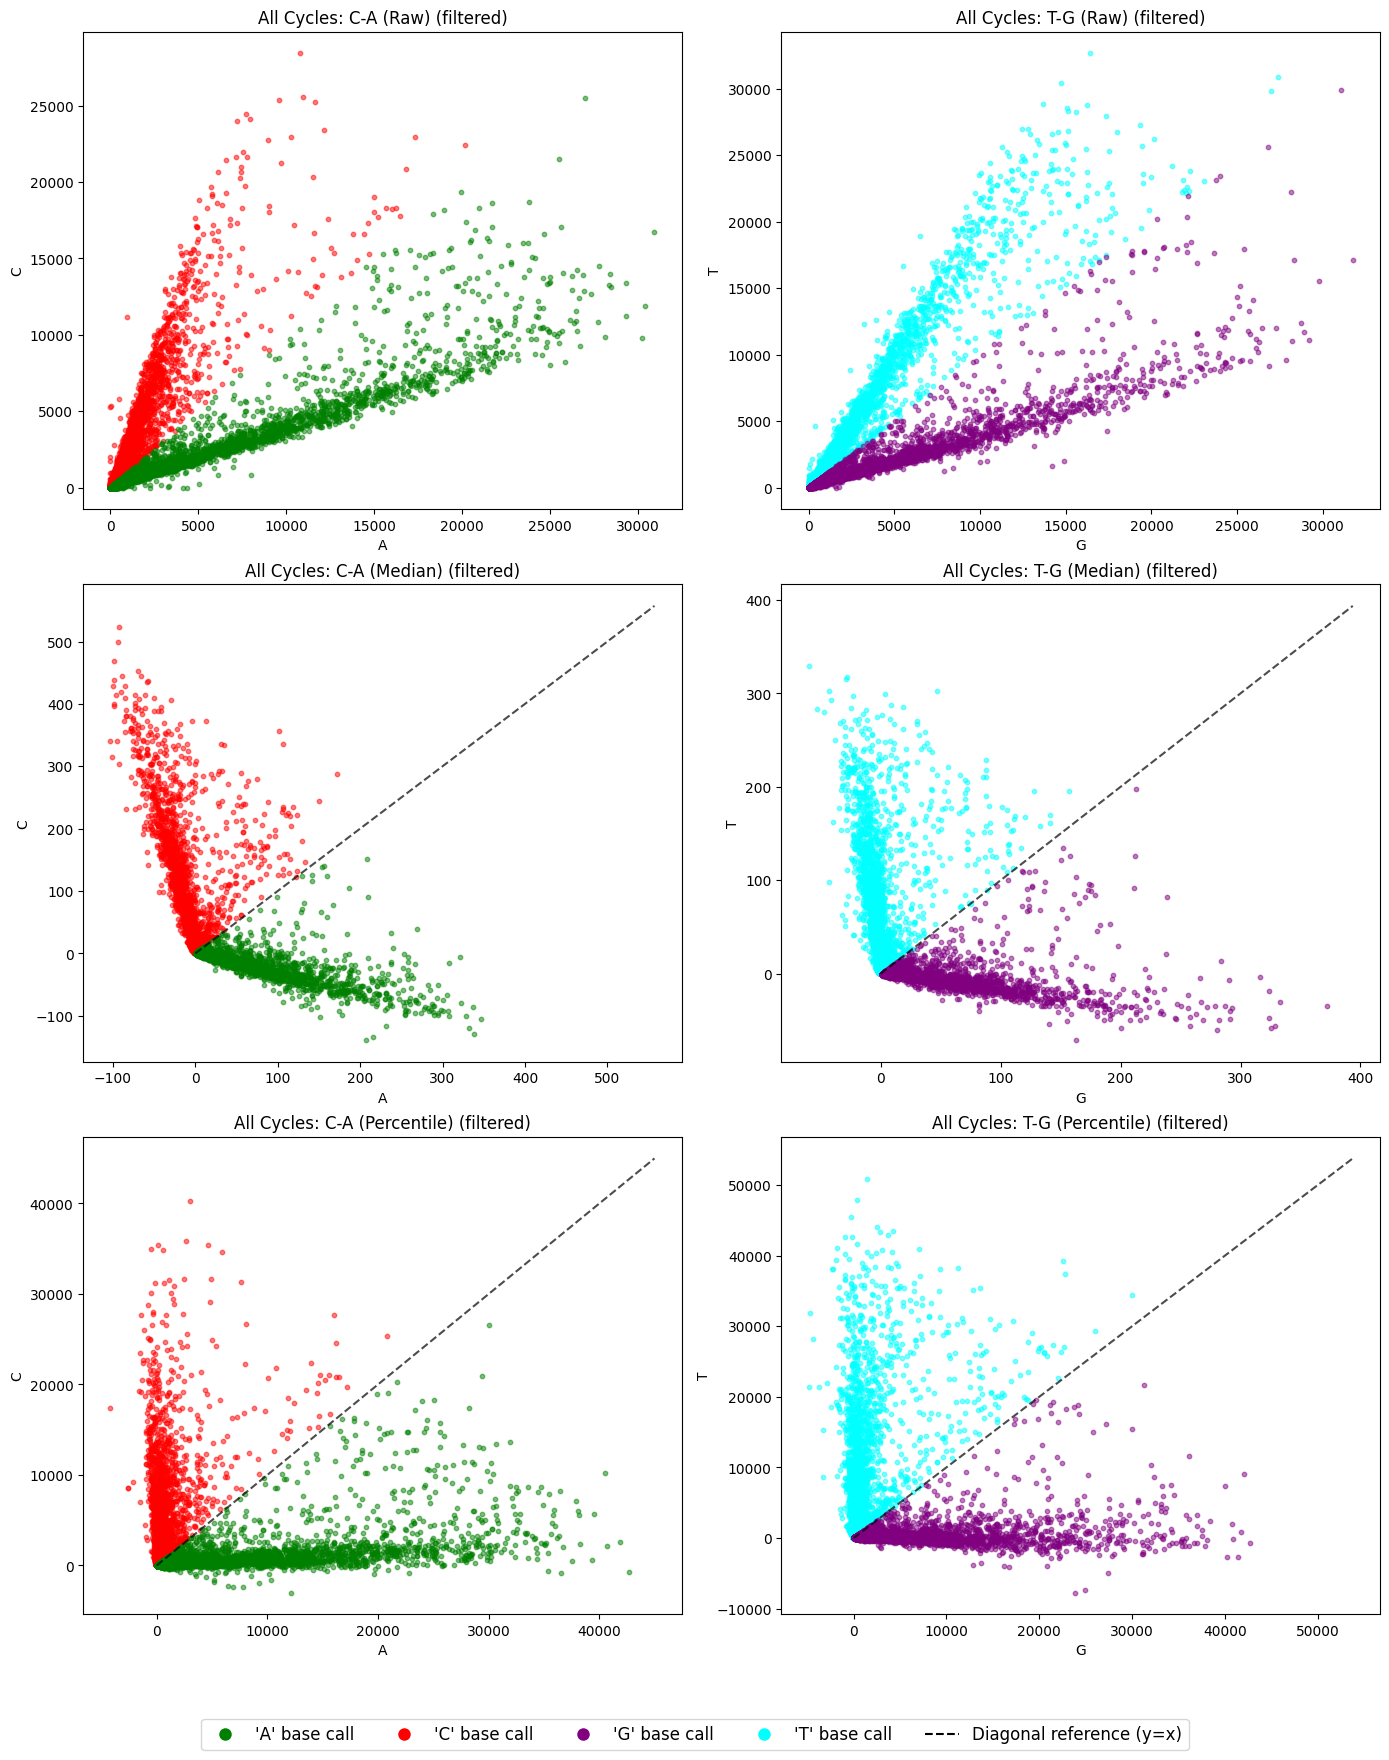

In [26]:
# Re-run extract_bases and call_reads with the new threshold
print("Extracted bases:")
df_bases = extract_bases(
    peaks, maxed, cells if SEGMENT_CELLS else nuclei, THRESHOLD_READS, wildcards=WILDCARDS, bases=BASES
)
display(df_bases)

print("Base intensity across cycles:")
ax = sns.pointplot(x="cycle", y="intensity", hue="channel", data=df_bases)
plt.show()

print("Intensity for each base:")
ax = sns.boxplot(
    x="channel", y="intensity", hue="channel", data=df_bases, showfliers=False
)
plt.show()

print("Different normalization methods")
plot_normalization_comparison(df_bases, base_order = BASES)

Called reads:


,read,cell,i,j,tile,well,barcode,Q_0,Q_1,Q_2,...,Q_9,Q_10,Q_11,Q_12,Q_13,Q_14,Q_15,Q_16,Q_min,peak
2,0,0,0,222,125,A2,CCTAGCAAACATGAATT,1.000000,1.000000,1.000000,...,1.000000,0.00000,1.000000,1.000000,0.000000,0.000000,0.738140,1.000000,0.000000,1
70,1,0,3,516,125,A2,GAGAGCCACAAGATTAG,0.000000,1.000000,1.000000,...,1.000000,0.00000,1.000000,0.738140,0.738140,1.000000,0.738140,0.738140,0.000000,1
138,2,0,4,531,125,A2,ATTATTTATTATGAATT,0.374577,0.286731,0.452048,...,0.602889,0.00000,0.557886,0.676716,0.189371,0.654537,1.000000,0.158436,0.000000,1
206,3,0,5,390,125,A2,TGCACCAAGGATGAAAT,0.514643,1.000000,1.000000,...,1.000000,0.00000,0.987885,0.602375,0.927701,0.195684,0.447588,0.364447,0.000000,1
274,4,0,6,511,125,A2,TAGTGCCACAGGGAGGG,0.568930,0.951674,1.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,0.925513,0.286443,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154838,2277,751,1454,1213,125,A2,CAAGTCCCAGTGATTCA,1.000000,0.277294,1.000000,...,1.000000,1.00000,1.000000,1.000000,0.452589,1.000000,0.000000,0.000000,0.000000,1
154974,2279,751,1455,1225,125,A2,TAAATTCCGTTCAAAAA,0.238122,0.000000,1.000000,...,1.000000,1.00000,0.228756,1.000000,1.000000,0.738140,1.000000,0.738140,0.000000,1
155042,2280,751,1456,1233,125,A2,AAAAAATTATAAAATTA,0.634788,0.000000,0.000000,...,0.738140,0.73814,0.000000,0.000000,0.000000,0.738140,1.000000,0.000000,0.000000,1
156130,2296,751,1464,1217,125,A2,AATAAATTATTTAGAAA,0.773706,0.000000,1.000000,...,1.000000,1.00000,1.000000,0.000000,0.738140,0.000000,0.000000,0.000000,0.000000,1


Barcode prefix matching (actual vs random)


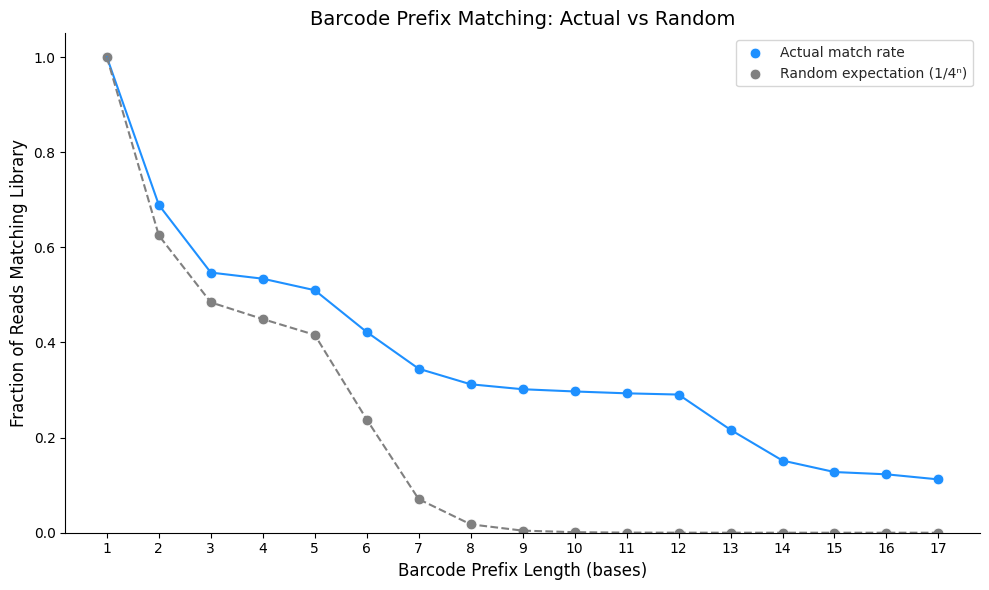

In [27]:
print("Called reads:")
df_reads = call_reads(df_bases, peaks_data=peaks)
display(df_reads)

print("Barcode prefix matching (actual vs random)")
# Use appropriate library column and parameters based on barcode type
if BARCODE_TYPE == "simple":
    _, _ = plot_barcode_prefix_matching(
        df_reads, 
        df_barcode_library, 
        library_col="prefix",
    )
else:
    # Multi-mode: include recombination column and sequencing order
    _, _ = plot_barcode_prefix_matching(
        df_reads, 
        df_barcode_library, 
        library_col="prefix_map",
        library_col_recomb="prefix_recomb",
        sequencing_order=SEQUENCING_ORDER,
    )
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Read Prioritization Method: Peak vs. Count

The `SORT_CALLS` parameter determines how barcodes are prioritized when assigning reads to cells. This choice depends on your sequencing protocol:

**Count Prioritization (`SORT_CALLS = "count"`):**
- Prioritizes barcodes based on the **number of spots** detected per cell
- **Recommended for mRNA barcode protocols** (e.g., IVT-based perturbations)
- Why: mRNA barcodes produce multiple spots per cell, so more spots = more confident call
- Best for protocols where barcode signal is distributed throughout the cell

**Peak Prioritization (`SORT_CALLS = "peak"`):**
- Prioritizes barcodes based on the **peak intensity** of spots
- **Recommended for DNA barcode protocols** (e.g., Zombie, T7 amplification)
- Why: DNA barcodes typically produce a singular, bright spot per cell
- Best for protocols with focused, high-intensity signal

**Default**: `"count"` is the default and works well for most applications.

### Read Mapping Parameters

**Common to both barcode modes:**
- `Q_MIN`: Minimum quality score for base reads (default: 0)
- `ERROR_CORRECT`: Enable read error correction (default: False). Error correction maps reads to the nearest library barcode within `MAX_DISTANCE` edit distance. This requires sufficient barcode complexity: the library must contain more unique barcodes than can be confused at the given edit distance. For a barcode of length L with edit distance D, error correction is reliable when `library_size >> (L choose D) * 3^D`. As a rule of thumb, avoid error correction if your barcode length minus the edit distance is less than the number of bases needed to uniquely identify each library member.
- `SORT_CALLS`: Method for prioritizing barcodes - 'count' for mRNA protocols, 'peak' for DNA protocols
- `N_BARCODES`: Number of ranked barcodes to store per cell. Default `2`. Each barcode gets its own quality columns (`Q_min_0`, `Q_min_1`, etc.).
- `MAX_DISTANCE`: Optional. Maximum edit distance for barcode matching (optional)

**Simple mode specific:**
- `PREFIX_COL`: Column in the barcode library with pre-computed prefixes (produced by `standardize_barcode_design`). Default: `"prefix"`.
- `BARCODE_COL`: Fallback for libraries without pre-computed prefixes — auto-truncates full barcode sequences to the appropriate length. **Cannot be used when cycles were skipped during imaging**, since skipped cycles produce non-contiguous prefixes that simple truncation cannot reproduce. Leave as `None` when using `PREFIX_COL`.

**Multi mode specific:**
- `MAP_START`, `MAP_END`: Cycle positions defining MAP region for first barcode
- `RECOMB_START`, `RECOMB_END`: Cycle positions defining RECOMB region
- `BARCODE_MAP`, `BARCODE_RECOMB`: Columns in barcode library for MAP/RECOMB sequences

**Recombination Quality Filtering (Multi-mode only):**
- `RECOMB_FILTER_COL`: Quality column in the reads data to use for filtering recombination calls. Set to `"Q_recomb"` to filter based on the minimum quality score across recombination cycles (computed by `prep_multi_reads`). Set to `None` to disable quality filtering.
- `RECOMB_Q_THRESH`: Quality score threshold for accepting recombination barcode calls. Reads with `RECOMB_FILTER_COL` below this threshold will have their recombination status set to undetermined. Default is 0.1.

**Note**: The output will include `no_recomb_0` and `no_recomb_1` columns indicating whether each cell's barcodes show recombination (True = no recombination detected, barcodes match library expectations).

The Q_min plot below helps determine optimal sequence quality cutoff:

Mapping rate vs. Q_min for determining optimal sequence quality cutoff:


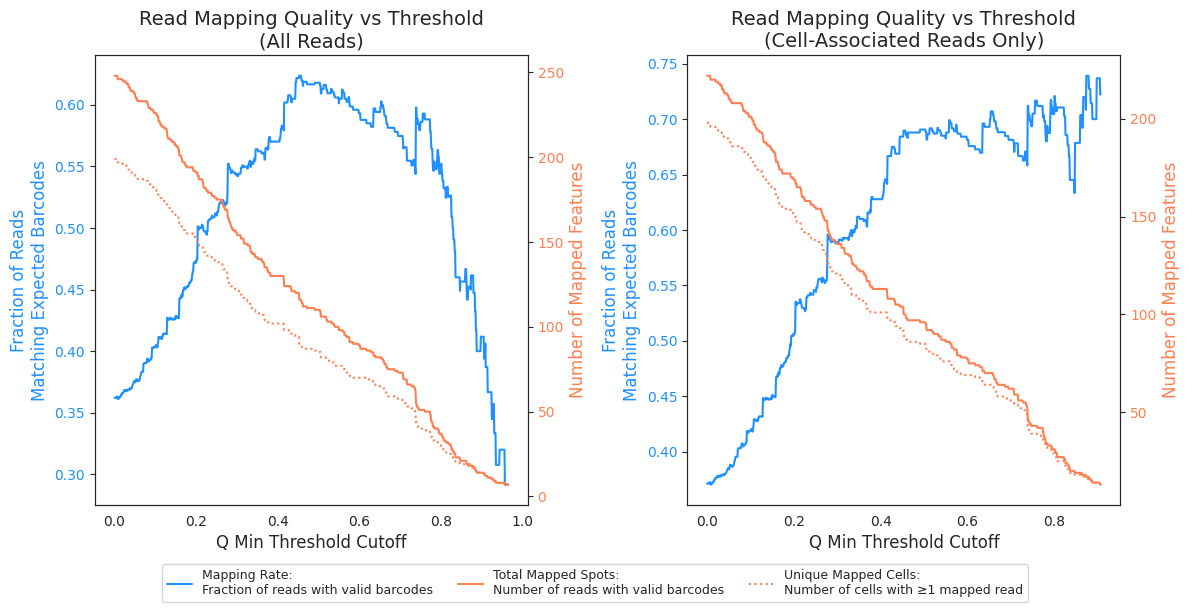

In [28]:
print("Mapping rate vs. Q_min for determining optimal sequence quality cutoff:")
plot_mapping_vs_threshold(df_reads, barcodes, "Q_min")
plt.show()

#### Left Plot (All Reads):
- Shows how Q_min threshold affects all detected reads
- Blue line: Mapping rate (fraction of reads matching expected barcodes)
- Solid red line: Total number of mapped spots (reads with valid barcodes)
- Dotted red line: Number of unique cells with at least one mapped read

#### Right Plot (Cell-Associated Reads Only):
- Shows the same metrics but only for reads associated with cells

#### Interpreting Q_min Results:
With our optimized peak threshold, these plots confirm that adjusting Q_min provides little benefit:
- The mapping rate (blue line) is already very high at Q_min = 0
- Increasing Q_min only marginally improves mapping rate 
- However, this comes at a significant cost:
  - Total mapped spots and mapped cells decreases substantially
- The small gain in mapping rate doesn't justify the large loss of data

In [29]:
# Common parameters for both modes
Q_MIN = 0.1
ERROR_CORRECT = True
SORT_CALLS = "peak"
MAX_DISTANCE = 1  # Optional: maximum edit distance for barcode matching
N_BARCODES = 2  # Number of ranked barcodes to store per cell

# Simple mode parameters (used when BARCODE_TYPE = "simple")
# PREFIX_COL: column of pre-computed prefixes produced by standardize_barcode_design — use this.
PREFIX_COL = "prefix"
# BARCODE_COL: fallback for libraries without pre-computed prefixes (auto-truncates full sequences).
# NOTE: cannot be used when cycles were skipped during imaging, since skipped cycles produce
# non-contiguous prefixes that simple truncation cannot reproduce. Leave as None if using PREFIX_COL.
# (BARCODE_COL is defined in Cell 23 — no need to redefine here.)

# Multi mode parameters (used when BARCODE_TYPE = "multi")
MAP_START = 1     # Start cycle for MAP region (e.g., 1), 1-indexed
MAP_END = 12       # End cycle for MAP region (e.g., 5)
RECOMB_START = 13  # Start cycle for RECOMB region (e.g., 6)
RECOMB_END = 17    # End cycle for RECOMB region (e.g., 11)
PREFIX_MAP = "prefix_map"  # Column with MAP region barcode sequences (e.g., "iBAR2")
PREFIX_RECOMB = "prefix_recomb"  # Column with RECOMB region barcode
RECOMB_FILTER_COL = "Q_recomb"  # Quality column for filtering recombination calls
RECOMB_Q_THRESH = 0.1           # Quality threshold (reads below this have undetermined recomb status)
BARCODE_INFO_COLS = None  # Optional: additional barcode info columns to include in output
DISTANCE_METRIC = "hamming"

In [30]:
if ERROR_CORRECT:
    import math
    d = MAX_DISTANCE if MAX_DISTANCE is not None else 1
    prefix_col_to_use = PREFIX_COL if BARCODE_TYPE == "simple" else "prefix_map"
    prefix_length = len(df_barcode_library[prefix_col_to_use].dropna().iloc[0])
    recommended_d = prefix_length - math.ceil(math.log(len(df_barcode_library), 4))

    if recommended_d <= 0:
        print("WARNING: Error correction not recommended — library too complex relative to cycles sequenced.")
    elif d > recommended_d:
        print(f"WARNING: MAX_DISTANCE={d} may be too aggressive. Recommended max edit distance: {recommended_d}.")
    else:
        print(f"Error correction parameters look appropriate (recommended max edit distance: {recommended_d}).")

Error correction parameters look appropriate (recommended max edit distance: 6).


Calling cells with barcode mapping...
Using cycle-based extraction: map cycles 1-12
Available quality columns: ['Q_0', 'Q_1', 'Q_10', 'Q_11', 'Q_12', 'Q_13', 'Q_14', 'Q_15', 'Q_16', 'Q_2', 'Q_3', 'Q_4', 'Q_5', 'Q_6', 'Q_7', 'Q_8', 'Q_9']
Maximum cycle available: 17
Requested mapping range: cycles 1-12
Requested recombination range: cycles 13-17
performing error correction


/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/brieflow/workflow/lib/sbs/call_cells.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reads[pre_correct_col] = df_reads[barcode_column]


Called 375 cells using multi mode


/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/brieflow/workflow/lib/sbs/call_cells.py:150: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reads[barcode_column] = error_correct_reads(


,well,tile,cell,cell_barcode_0,Q_0_0,Q_1_0,Q_2_0,Q_3_0,Q_4_0,Q_5_0,...,Q_13_1,Q_14_1,Q_15_1,Q_16_1,Q_min_1,Q_recomb_1,no_recomb_1,cell_barcode_peak_1,gene_symbol_0,gene_symbol_1
0,A2,125,2,TGCGTTGATGAG,0.707970,1.000000,1.000000,1.000000,0.887301,0.808958,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,KCND3,NaN
1,A2,125,15,CGGACGGAATAA,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,EBF3,NaN
2,A2,125,17,CAGTCAGTATGG,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,AP3B1,NaN
3,A2,125,19,TCCAGCGACTAA,0.156241,0.470483,0.949402,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,PAH,NaN
4,A2,125,20,CGGGTACGTCTG,1.000000,0.919047,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,MYT1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,A2,125,718,ATTTTTTTTTTT,0.602060,0.773706,0.795880,0.575171,0.666667,0.634788,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
371,A2,125,737,AATTATTTTTTT,0.657625,0.676716,1.000000,1.000000,0.309804,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
372,A2,125,738,ATTTTTTTTTTT,0.500000,0.525299,0.803792,0.642122,0.642122,0.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
373,A2,125,740,ATTTTTTTTTTT,0.602060,1.000000,0.919047,0.452048,0.575171,0.277294,...,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN


...

Summary of the fraction of cells mapping to one barcode:


,well,tile,fraction of cells mapping to 1 gene symbols
1,A2,125,0.304927


Summary of the fraction of cells mapping to any barcode:


,well,tile,fraction of cells mapping to >=1 gene symbols
1,A2,125,0.378162


Histogram of the number of reads per cell:


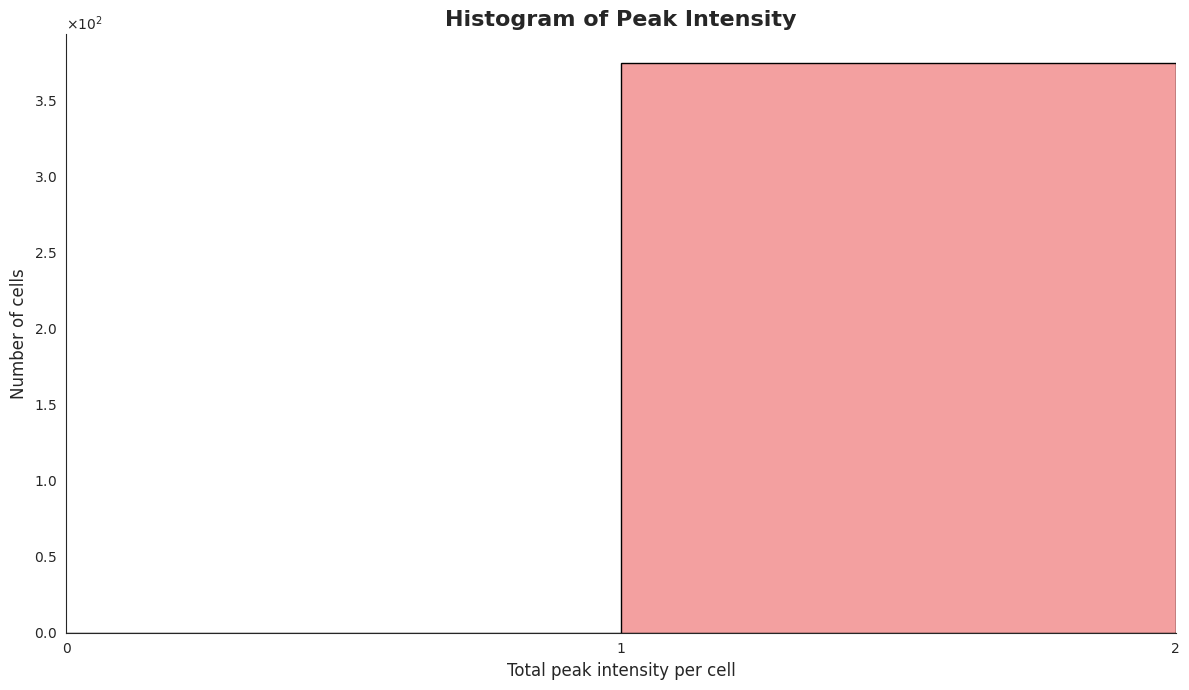

Histogram of the number of counts of each unique gene symbols:


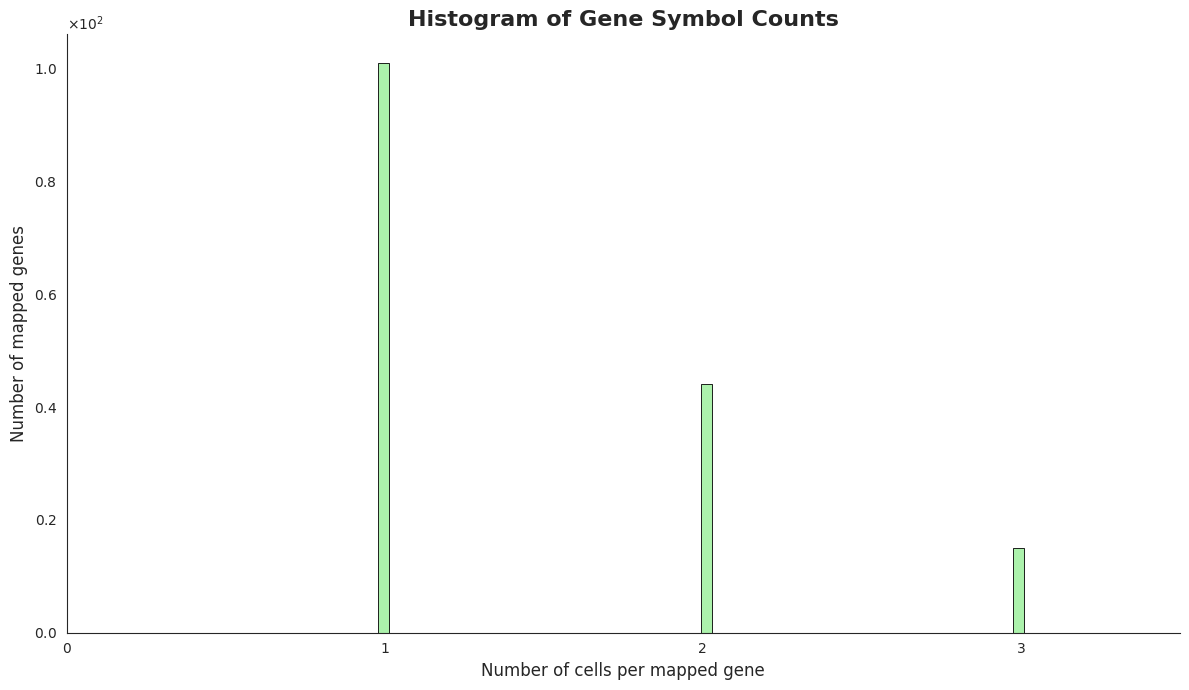

In [31]:
print("Calling cells with barcode mapping...")

if BARCODE_TYPE == "simple":
    df_cells = call_cells(
        df_reads, 
        df_barcode_library=df_barcode_library, 
        q_min=Q_MIN, 
        barcode_col=BARCODE_COL, 
        prefix_col=PREFIX_COL, 
        error_correct=ERROR_CORRECT,
        sort_calls=SORT_CALLS,
        max_distance=MAX_DISTANCE,
        n_barcodes=N_BARCODES,
    )
    
elif BARCODE_TYPE == "multi":
    df_cells = call_cells(
        reads_data=df_reads,
        df_barcode_library=df_barcode_library,
        q_min=Q_MIN,
        map_start=MAP_START,
        map_end=MAP_END,
        prefix_map=PREFIX_MAP,
        recomb_start=RECOMB_START,
        recomb_end=RECOMB_END,
        prefix_recomb=PREFIX_RECOMB,
        recomb_filter_col=RECOMB_FILTER_COL,
        recomb_q_thresh=RECOMB_Q_THRESH,
        error_correct=ERROR_CORRECT,
        sort_calls=SORT_CALLS,
        max_distance=MAX_DISTANCE,
        n_barcodes=N_BARCODES,
        barcode_info_cols=BARCODE_INFO_COLS,
        distance_metric=DISTANCE_METRIC,
    )

print(f"Called {len(df_cells)} cells using {BARCODE_TYPE} mode")
display(df_cells)

# Show recombination statistics for multi-mode
if BARCODE_TYPE == "multi":
    total_mapped_cells = len(df_cells)
    if "no_recomb_0" in df_cells.columns:
        cells_no_recomb = df_cells["no_recomb_0"].sum()
        no_recomb_percent = (cells_no_recomb / total_mapped_cells * 100) if total_mapped_cells > 0 else 0
        print(f"  Recombination Statistics:")
        print(f"  Total mapped cells: {total_mapped_cells}")
        print(f"  Cells with no recombination detected: {cells_no_recomb} ({no_recomb_percent:.1f}%)")

print("Minimal phenotype features:")
df_sbs_info = extract_phenotype_minimal(
    phenotype_data=nuclei, nuclei_data=nuclei, wildcards=WILDCARDS
)
display(df_sbs_info)

print("Summary of the fraction of cells mapping to one barcode:")
one_barcode_mapping = plot_cell_mapping_heatmap(
    df_cells,
    df_sbs_info,
    barcodes,
    mapping_to="one",
    mapping_strategy="gene symbols",
    return_plot=False,
    return_summary=True,
)
display(one_barcode_mapping)

print("Summary of the fraction of cells mapping to any barcode:")
any_barcode_mapping = plot_cell_mapping_heatmap(
    df_cells,
    df_sbs_info,
    barcodes,
    mapping_to="any",
    mapping_strategy="gene symbols",
    return_plot=False,
    return_summary=True,
)
display(any_barcode_mapping)

print("Histogram of the number of reads per cell:")
outliers = plot_cell_metric_histogram(df_cells, sort_by=SORT_CALLS)
plt.show()

print("Histogram of the number of counts of each unique gene symbols:")
outliers = plot_gene_symbol_histogram(df_cells)
plt.show()

In [32]:
#import numpy as np
#prefixes = df_barcode_library["prefix_map"].astype(str).unique()
#L = len(prefixes[0])
#print(f"{len(prefixes)} unique MAP prefixes, length {L}")
#arr = np.array([[ord(c) for c in s] for s in prefixes])
#counts = np.zeros(L + 1, dtype=int); min_d = L
#for i in range(len(arr)):
#    d = (arr[i] != arr[i+1:]).sum(axis=1)
#    if len(d):
#        counts += np.bincount(d, minlength=L + 1)
#        min_d = min(min_d, int(d.min()))
#print("min pairwise Hamming distance:", min_d)
#print("pairs at distance 0..6:", counts[:7])

## Automated Parameter Optimization (Optional)

This section provides an automated way to optimize SBS parameters by testing multiple parameter combinations and evaluating their performance. This is particularly useful when you're unsure about the optimal values for `PEAK_WIDTH` and `THRESHOLD_READS`.

**How it works:**
1. Define a grid of parameters to test (e.g., different peak widths and threshold values)
2. For each combination, the full SBS pipeline is run automatically
3. Results are evaluated using a metric function
4. Multi-panel visualizations show the primary optimization metric alongside secondary metrics to help you understand trade-offs
5. After identifying optimal parameters, subset the results and re-evaluate with detailed plots

**Available metrics:**
- `metric_specificity`: (Recommended) Ratio of cells with exactly one barcode to cells with any barcode. Higher is better (1.0 = perfect, all mapped cells have exactly one barcode).
- `metric_one_barcode_fraction`: Fraction of all cells that map to exactly one barcode. Useful when maximizing total mapped cells is a priority.
- `metric_any_barcode_fraction`: Fraction of all cells that map to any barcode (one or more). Useful for understanding overall mapping coverage.

**Note:** This can take several minutes depending on the number of combinations tested. Start with a small grid for initial exploration.

In [33]:
# # Uncomment to run automated parameter search

# from lib.sbs.automated_parameter_search import (
#     automated_parameter_search,
#     visualize_parameter_results,
#     get_best_parameters,
#     metric_one_barcode_fraction,
#     metric_any_barcode_fraction,
#     metric_specificity,
# )

# # Define parameter grid to test
# # This is the primary input you'll customize for your analysis
# param_grid = {
#     'peak_width': [5, 10, 15, 20],           # Test different peak detection widths
#     'threshold_reads': [50, 100, 150, 200],  # Test different intensity thresholds
# }

In [34]:
# # Select optimization metric
# # metric_specificity is recommended as it balances quality (one barcode per cell) with coverage
# OPTIMIZATION_METRIC = metric_specificity

# # Define parameters that stay constant across all tests
# fixed_params = {
#     'max_filter_width': MAX_FILTER_WIDTH,
#     'call_reads_method': CALL_READS_METHOD,
#     'q_min': Q_MIN,
#     'error_correct': ERROR_CORRECT,
#     'sort_calls': SORT_CALLS,
# }

# # Add mode-specific parameters to fixed_params
# if BARCODE_TYPE == "simple":
#     fixed_params.update({
#         'barcode_col': BARCODE_COL,
#         'prefix_col': PREFIX_COL,
#     })
#     if MAX_DISTANCE is not None:
#         fixed_params['max_distance'] = MAX_DISTANCE
        
# elif BARCODE_TYPE == "multi":
#     fixed_params.update({
#         'map_start': MAP_START,
#         'map_end': MAP_END,
#         'prefix_map': PREFIX_MAP,
#         'recomb_start': RECOMB_START,
#         'recomb_end': RECOMB_END,
#         'prefix_recomb': PREFIX_RECOMB,
#         'recomb_filter_col': RECOMB_FILTER_COL,
#         'recomb_q_thresh': RECOMB_Q_THRESH,
#     })
#     if MAX_DISTANCE is not None:
#         fixed_params['max_distance'] = MAX_DISTANCE
#     if BARCODE_INFO_COLS is not None:
#         fixed_params['barcode_info_cols'] = BARCODE_INFO_COLS

In [35]:
# # Run automated parameter search and evaluation
# print(f"Testing {len(param_grid['peak_width']) * len(param_grid['threshold_reads'])} parameter combinations...")
# results_df, df_cells_all = automated_parameter_search(
#     aligned_images=aligned,
#     mask=cells if SEGMENT_CELLS else nuclei,  # Use 'cells' if spots are in cell bodies, 'nuclei' if spots are nuclear
#     barcodes=barcodes,
#     df_barcode_library=df_barcode_library,
#     wildcards=WILDCARDS,
#     bases=BASES,
#     extra_channel_indices=EXTRA_CHANNEL_INDICES,
#     param_grid=param_grid,
#     fixed_params=fixed_params,
#     metric_fn=OPTIMIZATION_METRIC,
#     barcode_type=BARCODE_TYPE,  # Pass the barcode type
#     verbose=True
# )

# # Visualize results with multiple metrics
# # This will show the primary metric (specificity) plus secondary metrics
# # (one-barcode mapping, any-barcode mapping) to understand trade-offs
# visualize_parameter_results(
#     results_df, 
#     df_cells=df_cells_all,  # Pass df_cells_all to compute secondary metrics
#     metric_name='metric_score',
#     show_secondary_metrics=True  # Show multiple metric panels
# )

# # Get best parameters based on the optimization metric
# best_params = get_best_parameters(results_df, metric_name='metric_score', maximize=True)

# # Subset df_cells_all to the best parameter combination for detailed evaluation
# print("\n" + "="*60)
# print("Evaluating best parameter combination in detail")
# print("="*60)
# df_cells_best = df_cells_all[
#     (df_cells_all['peak_width'] == best_params['peak_width']) &
#     (df_cells_all['threshold_reads'] == best_params['threshold_reads'])
# ].copy()

# # Remove parameter tracking columns for cleaner display
# df_cells_best = df_cells_best.drop(columns=['peak_width', 'threshold_reads'], errors='ignore')

# print(f"\nBest parameters produce {len(df_cells_best)} called cells")
# display(df_cells_best)

# # Re-run all evaluation plots with the best parameter set
# print("\nSummary of the fraction of cells mapping to one barcode:")
# one_barcode_mapping_best = plot_cell_mapping_heatmap(
#     df_cells_best,
#     df_sbs_info,
#     barcodes,
#     mapping_to="one",
#     mapping_strategy="gene symbols",
#     shape="6W_sbs",
#     return_plot=False,
#     return_summary=True,
# )
# display(one_barcode_mapping_best)

# print("\nSummary of the fraction of cells mapping to any barcode:")
# any_barcode_mapping_best = plot_cell_mapping_heatmap(
#     df_cells_best,
#     df_sbs_info,
#     barcodes,
#     mapping_to="any",
#     mapping_strategy="gene symbols",
#     shape="6W_sbs",
#     return_plot=False,
#     return_summary=True,
# )
# display(any_barcode_mapping_best)

# print("\nHistogram of the number of reads per cell:")
# outliers_best = plot_cell_metric_histogram(df_cells_best, sort_by=SORT_CALLS)
# plt.show()

# print("\nHistogram of the number of counts of each unique gene symbols:")
# outliers_best = plot_gene_symbol_histogram(df_cells_best)
# plt.show()

# # Optionally: Update your parameters with the best values for use in the config
# # PEAK_WIDTH = int(best_params['peak_width'])
# # THRESHOLD_READS = int(best_params['threshold_reads'])

## Add sbs process parameters to config file

In [36]:
# Add sbs section
config["sbs"] = {
    "alignment_method": ALIGNMENT_METHOD,
    "channel_names": CHANNEL_NAMES,
    "upsample_factor": UPSAMPLE_FACTOR,
    "window": WINDOW,
    "skip_cycles_indices": SKIP_CYCLES_INDICES,
    "manual_background_cycle_index": MANUAL_BACKGROUND_CYCLE_INDEX,
    "manual_channel_mapping": MANUAL_CHANNEL_MAPPING,
    "extra_channel_indices": EXTRA_CHANNEL_INDICES,
    "max_filter_width": MAX_FILTER_WIDTH,
    "spot_detection_method": SPOT_DETECTION_METHOD,
    "dapi_cycle": DAPI_CYCLE,
    "dapi_cycle_index": DAPI_CYCLE_INDEX,
    "cyto_cycle": CYTO_CYCLE,
    "cyto_cycle_index": CYTO_CYCLE_INDEX,
    "dapi_index": DAPI_INDEX,
    "cyto_index": CYTO_INDEX,
    "segmentation_method": SEGMENTATION_METHOD,
    "gpu": GPU,
    "reconcile": RECONCILE,
    "segment_cells": SEGMENT_CELLS,
    "df_barcode_library_fp": DF_BARCODE_LIBRARY_FP,
    "threshold_peaks": THRESHOLD_READS,
    "call_reads_method": CALL_READS_METHOD,
    "bases": BASES,
    "q_min": Q_MIN,
    "error_correct": ERROR_CORRECT,
    "sort_calls": SORT_CALLS,
    "n_barcodes": N_BARCODES,
    "barcode_type": BARCODE_TYPE,
}

# Add max_distance if specified
if MAX_DISTANCE is not None:
    config["sbs"]["max_distance"] = MAX_DISTANCE

# Add barcode type specific parameters
if BARCODE_TYPE == "simple":
    config["sbs"].update({
        "barcode_col": BARCODE_COL,
        "prefix_col": PREFIX_COL,
    })
elif BARCODE_TYPE == "multi":
    config["sbs"].update({
        "map_start": MAP_START,
        "map_end": MAP_END,
        "prefix_map": PREFIX_MAP,
        "recomb_start": RECOMB_START,
        "recomb_end": RECOMB_END,
        "prefix_recomb": PREFIX_RECOMB,
    })
    # Add optional multi-mode parameters if defined
    if RECOMB_FILTER_COL is not None:
        config["sbs"]["recomb_filter_col"] = RECOMB_FILTER_COL
    if RECOMB_Q_THRESH is not None:
        config["sbs"]["recomb_q_thresh"] = RECOMB_Q_THRESH
    if BARCODE_INFO_COLS is not None:
        config["sbs"]["barcode_info_cols"] = BARCODE_INFO_COLS

# Add spot detection method specific parameters
if SPOT_DETECTION_METHOD == "standard":
    config["sbs"].update({
        "peak_width": PEAK_WIDTH,
    })
elif SPOT_DETECTION_METHOD == "spotiflow":
    config["sbs"].update({
        "spotiflow_cycle_index": SPOTIFLOW_CYCLE_INDEX,
        "spotiflow_model": SPOTIFLOW_MODEL,
        "spotiflow_threshold": SPOTIFLOW_THRESHOLD,
        "spotiflow_min_distance": SPOTIFLOW_MIN_DISTANCE,
        "spotiflow_remove_index": EXTRA_CHANNEL_INDICES,
    })

# Add method-specific parameters based on segmentation method
if SEGMENTATION_METHOD == "cellpose":
    config["sbs"].update({
        "nuclei_diameter": NUCLEI_DIAMETER,
        "cell_diameter": CELL_DIAMETER,
        "nuclei_flow_threshold": NUCLEI_FLOW_THRESHOLD,
        "nuclei_cellprob_threshold": NUCLEI_CELLPROB_THRESHOLD,
        "cell_flow_threshold": CELL_FLOW_THRESHOLD,
        "cell_cellprob_threshold": CELL_CELLPROB_THRESHOLD,
        "cellpose_model": CELLPOSE_MODEL,
    })
    # Add helper_index only if it's defined
    if HELPER_INDEX is not None:
        config["sbs"]["helper_index"] = HELPER_INDEX
elif SEGMENTATION_METHOD == "stardist":
    config["sbs"].update({
        "stardist_model": STARDIST_MODEL,
        "nuclei_prob_threshold": NUCLEI_PROB_THRESHOLD,
        "nuclei_nms_threshold": NUCLEI_NMS_THRESHOLD,
        "cell_prob_threshold": CELL_PROB_THRESHOLD,
        "cell_nms_threshold": CELL_NMS_THRESHOLD,
    })
elif SEGMENTATION_METHOD == "watershed":
    config["sbs"].update({
        "threshold_dapi": THRESHOLD_DAPI,
        "nucleus_area_min": NUCLEUS_AREA[0],
        "nucleus_area_max": NUCLEUS_AREA[1],
        "threshold_cell": THRESHOLD_CELL,
    })

# Convert tuples to lists before dumping
safe_config = convert_tuples_to_lists(config)

# Write the updated configuration back with markdown-style comments
with open(CONFIG_FILE_PATH, "w") as config_file:
    # Write the introductory markdown-style comments
    config_file.write(CONFIG_FILE_HEADER)

    # Dump the updated YAML structure, keeping markdown comments for sections
    yaml.dump(safe_config, config_file, default_flow_style=False, sort_keys=False)

In [37]:
import pandas as pd
stable5 = pd.read_csv("library_design_20260107_stable5_5GP.csv")
stable5["map12"] = stable5["prefix"].str[:12]
map2gene = dict(zip(stable5["map12"], stable5["gene_symbol"]))

cells = pd.concat([pd.read_parquet(f"brieflow_output/sbs/parquets/P-1_W-{w}__cells.parquet")
                   for w in ["C2","C3","C4"]], ignore_index=True)
assert cells["cell_barcode_0"].dropna().str.len().mode()[0] == 12   # sanity: it's the 12-base MAP
cells["stable5_gene"] = cells["cell_barcode_0"].map(map2gene)
print(cells["stable5_gene"].value_counts(dropna=False))   # cells per gene (NaN = no exact match)
print(cells["cell_barcode_0"].value_counts().head(10))    # cells per MAP barcode

stable5_gene
NaN       19731
KCNQ2      7071
NT         6448
TARDBP     5635
SCN2A         8
Name: count, dtype: int64
cell_barcode_0
GGGCAACACACC    7071
GGGTATTGCCAA    6446
CACCCTCCGTTC    5635
GATAAGTATCAG    2563
TCAGACTGTGTC    2503
ACCACTAGCCCA    2419
TGCTGGCTGACA    2156
TTCCGGTCGATT    1455
ATTTTTTTTTTT     893
TTCCGTTCGATT     432
Name: count, dtype: Int64


/tmp/ipykernel_11351/832259340.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cells = pd.concat([pd.read_parquet(f"brieflow_output/sbs/parquets/P-1_W-{w}__cells.parquet")


In [38]:
from lib.sbs.call_cells import call_cells
stable5_lib = pd.DataFrame({
    "prefix_map":    stable5["prefix"].str[:12],
    "prefix_recomb": stable5["prefix"].str[12:17],
    "gene_symbol":   stable5["gene_symbol"],
})
reads_c = pd.concat([pd.read_parquet(f"brieflow_output/sbs/parquets/P-1_W-{w}__reads.parquet")
                     for w in ["C2","C3","C4"]], ignore_index=True)
cells_c = call_cells(reads_c, df_barcode_library=stable5_lib, q_min=0.1,
                     map_start=1, map_end=12, prefix_map="prefix_map",
                     recomb_start=13, recomb_end=17, prefix_recomb="prefix_recomb",
                     sort_calls="peak", error_correct=True, max_distance=2,
                     distance_metric="levenshtein", n_barcodes=2)
print(cells_c["gene_symbol_0"].value_counts(dropna=False))

Using cycle-based extraction: map cycles 1-12
Available quality columns: ['Q_0', 'Q_1', 'Q_10', 'Q_11', 'Q_12', 'Q_13', 'Q_14', 'Q_15', 'Q_16', 'Q_2', 'Q_3', 'Q_4', 'Q_5', 'Q_6', 'Q_7', 'Q_8', 'Q_9']
Maximum cycle available: 17
Requested mapping range: cycles 1-12
Requested recombination range: cycles 13-17
performing error correction


/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/brieflow/workflow/lib/sbs/call_cells.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reads[pre_correct_col] = df_reads[barcode_column]
/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/brieflow/workflow/lib/sbs/call_cells.py:150: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reads[barcode_column] = error_correct_reads(


gene_symbol_0
NaN       14113
KCNQ2      7862
NT         7143
TARDBP     7061
SCN2A      2714
Name: count, dtype: int64


/home/jovyan/workbench/ops/brieflow-analysis-ASD-443-6GP/brieflow/workflow/lib/sbs/call_cells.py:317: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  df_cells = df_cells.query("cell > 0")


In [39]:
#def cell_mapping_overview(df_cells, df_sbs_info, barcodes=None):
#    c = df_cells.copy()
#    bc1 = "cell_barcode_1" in c.columns
#    gn1 = "gene_symbol_1" in c.columns
#    if barcodes is None:                          # barcode = any called barcode (matches original overview)
#        c["b0"], c["b1"] = c["cell_barcode_0"].notna(), (c["cell_barcode_1"].notna() if bc1 else False)
#    else:                                         # barcode = present in this library
#        c["b0"], c["b1"] = c["cell_barcode_0"].isin(barcodes), (c["cell_barcode_1"].isin(barcodes) if bc1 else False)
#    c["g0"], c["g1"] = c["gene_symbol_0"].notna(), (c["gene_symbol_1"].notna() if gn1 else False)
#    m = df_sbs_info[["well","tile","cell"]].merge(
#        c[["well","tile","cell","b0","b1","g0","g1"]], how="left", on=["well","tile","cell"])
#    m[["b0","b1","g0","g1"]] = m[["b0","b1","g0","g1"]].fillna(False).astype(int)
#    m["nbar"], m["ngene"] = m.b0+m.b1, m.g0+m.g1
#    rows = []
#    for well, x in m.groupby("well"):
#        rows.append({"well": well, "total_cells__count": len(x),
#                     "1_barcode_cells__count": int((x.nbar==1).sum()),
#                     "1_or_more_barcodes__count": int((x.nbar>0).sum()),
#                    "1_gene_cells__count": int((x.ngene==1).sum()),
#                    "1_or_more_genes__count": int((x.ngene>0).sum())})
#    out = pd.DataFrame(rows)
#    for col in ["1_barcode_cells","1_or_more_barcodes","1_gene_cells","1_or_more_genes"]:
#        out[col+"__percent"] = 100*out[col+"__count"]/out["total_cells__count"]
#    return out
#
#sbs_c = pd.concat([pd.read_parquet(f"brieflow_output/sbs/parquets/P-1_W-{w}__sbs_info.parquet")
#                   for w in ["C2","C3","C4"]], ignore_index=True)
#print(cell_mapping_overview(cells_c, sbs_c))     # barcode≈47% (unchanged), gene now meaningful

mapped 675 / 2320 reads to a gene
plotting 387 cells


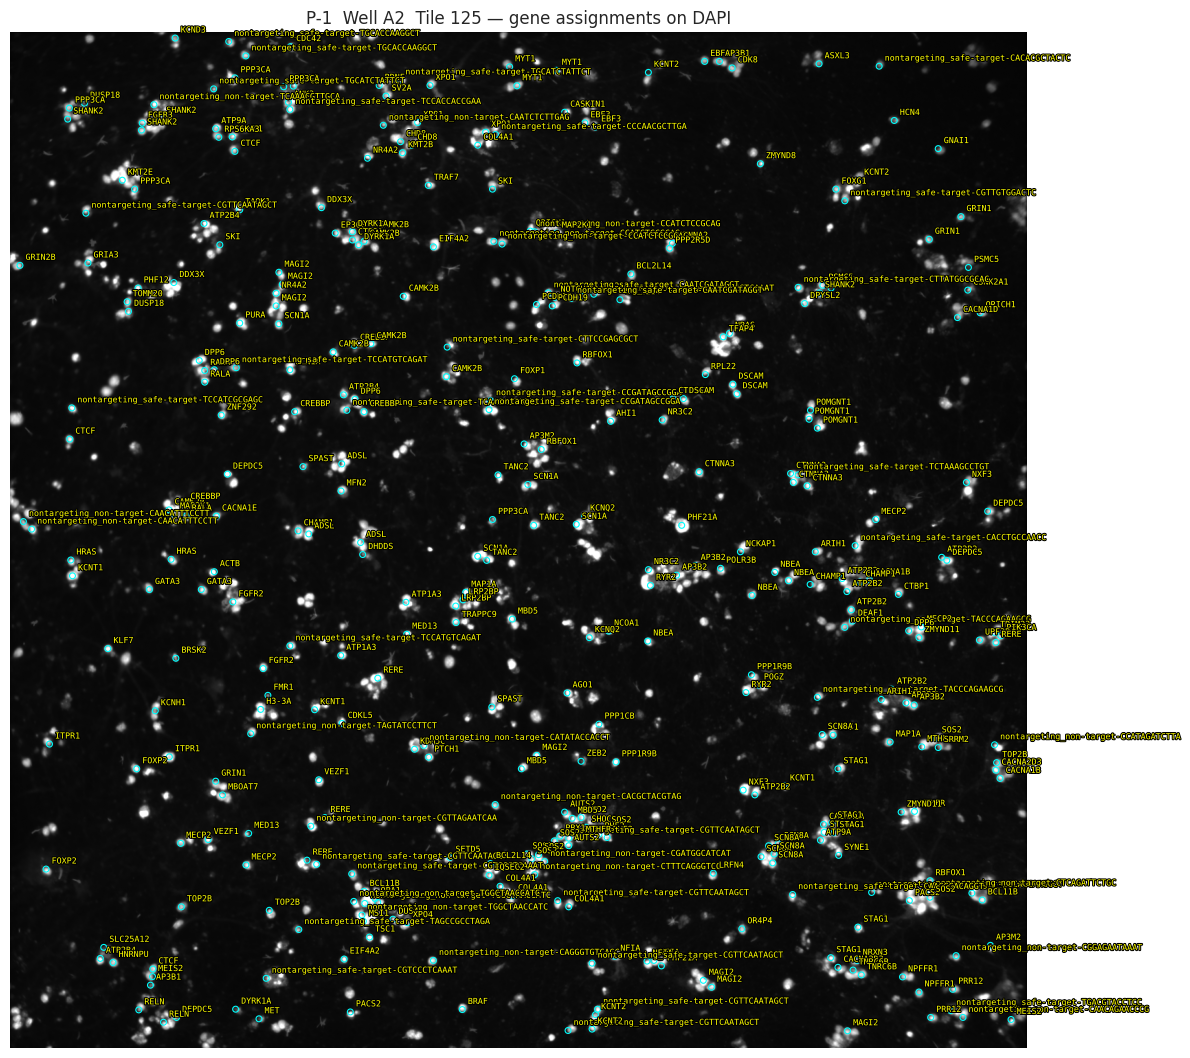

In [40]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from tifffile import imread

root = "brieflow_output/sbs"
aligned = imread(f"{root}/images/P-1_W-A2_T-125__aligned.tiff")   # (CYCLE, CHANNEL, I, J) = (17, 5, 1480, 1480)
reads   = pd.read_csv(f"{root}/tsvs/P-1_W-A2_T-125__reads.tsv", sep="\t")

# --- map 17 bp barcode -> gene_symbol via library ---
# barcode = prefix_map (first 12) + prefix_recomb (last 5), per sequencing_order="map_recomb"
lib = pd.read_csv("config/barcode_library.tsv", sep="\t")   # prefix_map is the FIRST column — no index_col!
lib_map = lib[["prefix_map", "gene_symbol"]].drop_duplicates("prefix_map")
reads["prefix_map"] = reads["barcode"].str[:12]
reads = reads.merge(lib_map, on="prefix_map", how="left")
print(f"mapped {reads['gene_symbol'].notna().sum()} / {len(reads)} reads to a gene")
# if that count is near zero, your read is recomb-first: use reads['barcode'].str[-12:] instead

# --- background: align/show the DAPI channel (channel 0), averaged across aligned cycles ---
bg = aligned[:, 0].mean(axis=0)                  # (I, J)

# --- spots ---
mapped_only = True                               # True = clean slide; False = every in-cell spot
per_cell    = True                               # True = one label per cell; False = one label per spot (troubleshooting)

r = reads.query("cell > 0").copy()
if mapped_only:
    r = r[r["gene_symbol"].notna()]

if per_cell:                                     # collapse to one row per cell: median position + majority-vote gene
    r = (r.dropna(subset=["gene_symbol"])
           .groupby("cell", as_index=False)
           .agg(i=("i", "median"), j=("j", "median"),
                gene_symbol=("gene_symbol", lambda s: s.mode().iat[0])))
    print(f"plotting {len(r)} cells")
else:
    print(f"plotting {len(r)} spots")

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(bg, cmap="gray", vmax=np.percentile(bg, 99.5))
ax.scatter(r.j, r.i, s=18, facecolors="none", edgecolors="cyan", linewidths=0.8)  # x=j, y=i

for _, row in r.iterrows():
    if pd.notna(row["gene_symbol"]):
        ax.annotate(row["gene_symbol"], (row.j, row.i), xytext=(4, 4),
                    textcoords="offset points", color="yellow", fontsize=6,
                    fontfamily="monospace",
                    path_effects=[pe.withStroke(linewidth=1.5, foreground="black")])

ax.set_title("P-1  Well A2  Tile 125 — gene assignments on DAPI"); ax.axis("off")
plt.tight_layout()
plt.savefig("A2_T125_gene_overlay.png", dpi=600, bbox_inches="tight")

In [41]:
def cell_mapping_overview(df_cells, df_sbs_info, barcodes=None, extra_rows=None):
    c = df_cells.copy()
    bc1, gn1 = "cell_barcode_1" in c.columns, "gene_symbol_1" in c.columns
    if barcodes is None:
        c["b0"], c["b1"] = c["cell_barcode_0"].notna(), (c["cell_barcode_1"].notna() if bc1 else False)
    else:
        c["b0"], c["b1"] = c["cell_barcode_0"].isin(barcodes), (c["cell_barcode_1"].isin(barcodes) if bc1 else False)
    c["g0"], c["g1"] = c["gene_symbol_0"].notna(), (c["gene_symbol_1"].notna() if gn1 else False)
    m = df_sbs_info[["well","tile","cell"]].merge(
        c[["well","tile","cell","b0","b1","g0","g1"]], how="left", on=["well","tile","cell"])
    m[["b0","b1","g0","g1"]] = m[["b0","b1","g0","g1"]].fillna(False).astype(int)
    m["nbar"], m["ngene"] = m.b0+m.b1, m.g0+m.g1
    rows = []
    for well, x in m.groupby("well"):
        rows.append({"well": well, "total_cells__count": len(x),
                     "1_barcode_cells__count": int((x.nbar==1).sum()),
                     "1_or_more_barcodes__count": int((x.nbar>0).sum()),
                     "1_gene_cells__count": int((x.ngene==1).sum()),
                     "1_or_more_genes__count": int((x.ngene>0).sum())})
    out = pd.DataFrame(rows)
    if extra_rows is not None:
        out = pd.concat([pd.DataFrame(extra_rows), out], ignore_index=True)
    for col in ["1_barcode_cells","1_or_more_barcodes","1_gene_cells","1_or_more_genes"]:
        out[col+"__percent"] = 100*out[col+"__count"]/out["total_cells__count"]
    return out

# A1, A2 pulled from bash mapping_overview output (counts only; percents recomputed)
extra = [
    {"well":"A1","total_cells__count":24413,"1_barcode_cells__count":9558,
     "1_or_more_barcodes__count":11931,"1_gene_cells__count":8979,"1_or_more_genes__count":10862},
    {"well":"A2","total_cells__count":36664,"1_barcode_cells__count":13784,
     "1_or_more_barcodes__count":17613,"1_gene_cells__count":11989,"1_or_more_genes__count":14722},
]
df = cell_mapping_overview(cells_c, sbs_c, extra_rows=extra)

# Append mean row across all wells
avg = {"well": "AVG"}
for col in ["total_cells__count","1_barcode_cells__count","1_or_more_barcodes__count",
            "1_gene_cells__count","1_or_more_genes__count"]:
    avg[col] = df[col].mean()
for col in ["1_barcode_cells","1_or_more_barcodes","1_gene_cells","1_or_more_genes"]:
        avg[col+"__percent"] = 100*avg[col+"__count"]/avg["total_cells__count"]
df = pd.concat([df, pd.DataFrame([avg])], ignore_index=True)

def compact_slide_table(df):
    def fmt(n, pct): return f"{int(n):,} ({pct:.1f}%)"
    t = pd.DataFrame({
        "well": df["well"],
        "total_cells": df["total_cells__count"].map(lambda v: f"{int(v):,}"),
        "1 gene":      [fmt(n,p) for n,p in zip(df["1_gene_cells__count"], df["1_gene_cells__percent"])],
        ">=1 gene":    [fmt(n,p) for n,p in zip(df["1_or_more_genes__count"], df["1_or_more_genes__percent"])],
        "1 barcode":   [fmt(n,p) for n,p in zip(df["1_barcode_cells__count"], df["1_barcode_cells__percent"])],
        ">=1 barcode": [fmt(n,p) for n,p in zip(df["1_or_more_barcodes__count"], df["1_or_more_barcodes__percent"])],
    })
    return t.set_index("well")

compact_slide_table(df)

NameError: name 'sbs_c' is not defined